# Data Loading and Visualisation

We develop a flexible framework for loading and visualising the optical and mass spectrometry imaging (MSI) datasets used in our study.

By manually comparing each of the folders shared with us, we found that all folders should have at least 10 items. Among these, the `.csv` and `.h5` format files will be useful in our analysis.

The rest contain mostly metadata, which are not relevant in our work. Some of the folders have 11 items, containing an extra `.DAT` file, while others contain 12 items, containing a further `imaging` subfolder within them.

**Regardless, we mainly use the `.h5` and `.csv` files in our analysis, and we will be focusing on loading these and visualising their contents.**

*(Note: Originally, one of the folders, `2024_08_01_0900225B_25um_10Hz.raw` did not contain a `.csv` file. However, there seemed to be 2 copies of this folder in 2 of the other folders: `2024_07_25_MK482_5_25um_10Hz.raw` and `2024_07_22_MK531_4_25um_10Hz.raw` (1 copy in each of these folders). We extracted these copies and compared them with the original. Both of these copies contained a `.csv` file, but one of these (the one in `2024_07_22_MK531_4_25um_10Hz.raw`) was empty. At the end, we retained the  folder that had the non-empty `.csv` and renamed it to `2024_08_01_0900225B_25um_10Hz.raw`. This is the folder we will be using from now.)*

## Setup

First, we set the working directory containing the folders of MSI data.

In [1]:
# Set working directory
import os
import pathlib
from pathlib import Path

loading_dir = Path(os.getcwd())
parent_dir = loading_dir.parent # Need this later
print(f"Current directory: {loading_dir}")

Current directory: /home/fs1620/MLBD_2024_25/ResearchProject/LiaDataAnalysis_GitHub/LoadingViz


Next, we specify the folders containing the `.h5` files of interest. In this case, we already know that these folders are located in the same directory as this notebook. We use this as the default setting for the following function. For more generic cases, the file path locations may be specified using the `base_path` parameter.

In [2]:
# ".ipynb_checkpoints" -> hidden directory created by Jupyter Notebook &
# JupyterLab to store checkpoint files for notebooks

def list_folders(exclude_names=(".ipynb_checkpoints",), search_dir=None, endswith=".raw"):
    """
    List all subfolders in a specified directory, optionally excluding certain names.

    This function scans the specified directory (or the current working directory if `None` 
    is provided) and returns a list of folder names, excluding those listed in 
    `exclude_names`. Useful for quickly enumerating datasets, experiments, or other 
    subdirectories while skipping unwanted folders.

    Parameters
    ----------
    exclude_names : tuple of str, optional
        Folder names to exclude from the result. 
        Defaults to (".ipynb_checkpoints",).
    search_dir : str or pathlib.Path, optional
        Directory path to search in. If not provided, defaults to the current 
        working directory.
    endswith : str, optional
        Restrict results to folder names that end with this string.
        Use an empty string ('') to include all folders.
        Defaults to '.raw'.

    Returns
    -------
    list
        A list of folders found given the search criteria.
    """

    endswith = "" if not endswith else endswith # allows user to pass in None if they want
    
    search_dir = Path(search_dir or os.getcwd())  # Default to current directory
    if not search_dir.exists() or not search_dir.is_dir():
        raise FileNotFoundError(f"Specified path is not a valid directory: {search_dir}")
    
    return [
        f.name for f in search_dir.iterdir()
        if f.is_dir() 
        and f.name not in exclude_names
        and (f.name.endswith(endswith) or endswith == "")
    ]

In [3]:
# Exclude any unwanted folders and list relevant ones from specified directory
folders = list_folders(search_dir = loading_dir, endswith = ".raw")
print(f'Number of folders: {len(folders)}\n')
print('Folder names:')
for folder in folders:
    print(f"{folder}")

Number of folders: 9

Folder names:
2024_07_22_MK483_3_25um_10Hz.raw
2024_07_25_MK503_3_25um_10Hz.raw
2024_07_23_MK478_4_25um_10Hz.raw
2024_08_01_0900225B_25um_10Hz.raw
2024_07_22_MK531_4_25um_10Hz.raw
2024_07_29_MK484_4_25um_10Hz.raw
2024_07_25_MK482_5_25um_10Hz.raw
2024_07_18_MK521_1_25um_10Hz.raw
2024_07_24_MK534_3_25um_10Hz.raw


Now, we create and store the paths specifying the locations of the `.h5` files in the working directory. In our case, a uniform naming scheme was used where all `.h5` files were labelled either `datacube.h5` or `datacube_aligned.h5`.

As we will see, their contents differ; the `datacube.h5` files contain intensity profiles over mass-to-charge (m/z) grids which are more or less unique to each sample. On the other hand, all aligned datacubes contain intensity spectra over an grid spanning 2947 m/z values, from about 50 to 1200. For the aligned files, the intensity profiles were all interpolated onto this common grid across all samples. These differences will become apparent as we proceed.

The interpolation was performed prior to our analysis. The grid of 2947 m/z values corresponds to the number of m/z values involved in the imaging of sample `2024_07_22_MK531_4_25um_10Hz`, and is the grid with the most number of points among all the unaligned datacubes (see below).

In [36]:
# Store file paths for the unaligned datacubes
file_paths_unaligned = [folder + '/datacube.h5' for folder in folders]
print(f'Number of unaligned files: {len(file_paths_unaligned)}\n')
for file_path in file_paths_unaligned:
    print(f'File path: {file_path}')

Number of unaligned files: 9

File path: 2024_07_22_MK483_3_25um_10Hz.raw/datacube.h5
File path: 2024_07_25_MK503_3_25um_10Hz.raw/datacube.h5
File path: 2024_07_23_MK478_4_25um_10Hz.raw/datacube.h5
File path: 2024_08_01_0900225B_25um_10Hz.raw/datacube.h5
File path: 2024_07_22_MK531_4_25um_10Hz.raw/datacube.h5
File path: 2024_07_29_MK484_4_25um_10Hz.raw/datacube.h5
File path: 2024_07_25_MK482_5_25um_10Hz.raw/datacube.h5
File path: 2024_07_18_MK521_1_25um_10Hz.raw/datacube.h5
File path: 2024_07_24_MK534_3_25um_10Hz.raw/datacube.h5


In [37]:
# Store file paths for the aligned datacubes
file_paths_aligned = [folder + '/datacube_aligned.h5' for folder in folders]
print(f'Number of aligned files: {len(file_paths_aligned)}\n')
for file_path in file_paths_aligned:
    print(f'File path: {file_path}')

Number of aligned files: 9

File path: 2024_07_22_MK483_3_25um_10Hz.raw/datacube_aligned.h5
File path: 2024_07_25_MK503_3_25um_10Hz.raw/datacube_aligned.h5
File path: 2024_07_23_MK478_4_25um_10Hz.raw/datacube_aligned.h5
File path: 2024_08_01_0900225B_25um_10Hz.raw/datacube_aligned.h5
File path: 2024_07_22_MK531_4_25um_10Hz.raw/datacube_aligned.h5
File path: 2024_07_29_MK484_4_25um_10Hz.raw/datacube_aligned.h5
File path: 2024_07_25_MK482_5_25um_10Hz.raw/datacube_aligned.h5
File path: 2024_07_18_MK521_1_25um_10Hz.raw/datacube_aligned.h5
File path: 2024_07_24_MK534_3_25um_10Hz.raw/datacube_aligned.h5


## Loading, inspecting, and interpreting the data in `.h5` files
Now, let us load in, format, and visualise the contents of the aligned and unaligned datacubes for specified files.

We note that the `.h5` files can be quite large, depending on the amount of data contained in them. In our case, these files sometimes exceeded 1GiB of memory. In other words, it is not optimal to keep these files open in memory persisently. To facilitate automatic closing once the relevant data has been extracted, we use the `with` keyword to cleanly open and close the `.h5` files, as shown below.

In [6]:
import h5py
from functools import partial

def print_attrs(name, obj, show_data=False, max_elements=2498):
    """
    Print attributes and basic information for a given HDF5 object.

    This function is designed to be used as a callback with the `h5py.File.visititems()` 
    method to explore the internal structure of an HDF5 (.h5) file. It prints the 
    attributes, type, and optionally data preview of each dataset or group.

    Parameters
    ----------
    name : str
        Path of the current object within the HDF5 hierarchy.
    obj : h5py.Group or h5py.Dataset
        HDF5 object (group or dataset) being inspected.
    show_data : bool, optional
        Whether to print a slice of the dataset contents. Default is False.
    max_elements : int, optional
        Maximum number of elements to display when `show_data=True`. 
        If the dataset exceeds this limit, only the first `max_elements` elements are shown.
        Default is 3000, which is larger than the number of m/z values in any file analysed.
        The number of m/z values across which spectra are recorded can be found by inspecting
        the datacube contents as shown in the examples below.
    """
    print(f"\n{'='*40}\nPath: {name}")
    for key, val in obj.attrs.items():
        print(f"[Attribute] {key}: {val}")

    if isinstance(obj, h5py.Dataset):
        print(f"[Dataset] Shape: {obj.shape}, Dtype: {obj.dtype}")
        if show_data:
            data_slice = obj[:] if obj.size <= max_elements else obj[:max_elements]
            print(f"[Data]\n{data_slice}")
    elif isinstance(obj, h5py.Group):
        print("[Group]")

def explore_h5(file_path, show_data=False, max_elements=3000):
    """
    Recursively explore and print the structure of an HDF5 (.h5) file.

    This function opens an HDF5 file in read-only mode and traverses all 
    datasets and groups, printing their attributes, shapes, and optionally 
    a preview of their contents.

    Parameters
    ----------
    file_path : str or pathlib.Path
        Path to the HDF5 (.h5) file.
    show_data : bool, optional
        Whether to print the actual dataset values (up to `max_elements` entries).
        Default is False.
    max_elements : int, optional
        Maximum number of data elements to print per dataset when `show_data=True`.
        Default is 3000, which is larger than the number of m/z values in any file analysed.
        The number of m/z values across which spectra are recorded can be found by inspecting
        the datacube contents as shown in the examples below.
    """
    file_path = Path(file_path) if type(file_path) != pathlib.PosixPath else file_path
    if not file_path.exists():
        raise FileNotFoundError(f"Specified file does not exist: {file_path}")

    try:
        with h5py.File(file_path, 'r') as f:
            f.visititems(partial(print_attrs, show_data=show_data, max_elements=max_elements))
    except Exception as e:
        print(f"Error reading HDF5 file: {e}")

Let us consider a concrete example, and compare the contents of the aligned and unaligned datacubes for one of the samples.

In [7]:
### Declare sample here ###
sample = 0

In [8]:
# Unaligned datacube.h5 file
print('Folder:', folders[sample])
explore_h5(file_paths_unaligned[sample], show_data = True)

Folder: 2024_07_22_MK483_3_25um_10Hz.raw

Path: datacube
[Dataset] Shape: (1967, 40000), Dtype: float64
[Data]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]

Path: dims
[Dataset] Shape: (2, 1), Dtype: float64
[Data]
[[200.]
 [200.]]

Path: mz
[Dataset] Shape: (1967, 1), Dtype: float64
[Data]
[[  50.15455627]
 [  50.30698013]
 [  50.91900253]
 ...
 [1198.58776855]
 [1198.88562012]
 [1199.79345703]]


In [9]:
# Aligned datacube.h5 file
print('Folder:', folders[sample])
explore_h5(file_paths_aligned[sample], show_data = True)

Folder: 2024_07_22_MK483_3_25um_10Hz.raw

Path: datacube
[Dataset] Shape: (2947, 40000), Dtype: float64
[Data]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]

Path: dims
[Dataset] Shape: (2, 1), Dtype: float64
[Data]
[[200.]
 [200.]]

Path: mz
[Dataset] Shape: (2947, 1), Dtype: float64
[Data]
[[  50.00944017]
 [  50.06884645]
 [  50.21388505]
 ...
 [1199.60176729]
 [1199.99214814]
 [1200.48873018]]


In this example, we see that the `datacube` object contained in the overall `datacube.h5` or `datacube_aligned.h5` file is a matrix where each column represents the mass spectrum of a pixel in a `(200,200)` mass spectrometry image (MSI), for a total of `40000` pixels.

Each row corresponds to an intensity value for a specific m/z, ratio (2947 m/z values in total for the aligned case, and 1967 values for the unaligned case), capturing ion intensities at different m/z ratios for each pixel.

The `dims` dataset provides the image dimensions, `(200,200)` pixels, and the `mz` array lists the specific m/z values corresponding to the rows in the datacube, for which intensity measurements have been made.

The above observations are generally true for all samples considered in our study.

We can further inspect each of the datasets contained in the `.h5` files in more detail.

In [10]:
import numpy as np

def keyload_h5(file_path, dataset_key=None, verbose=False, return_dataset = False):
    """
    Inspect a specific dataset within an HDF5 (.h5) file.

    This function enables inspection of a particular dataset (identified by its key)
    in an HDF5 file used for exploring MSI datacubes.
    It prints dataset dimensions, detects missing values,
    and optionally provides additional diagnostic information
    and returns the loaded dataset.

    Parameters
    ----------
    file_path : str or pathlib.Path
        Path to the HDF5 (.h5) file to inspect.
    dataset_key : str, optional
        Key identifying the dataset within the HDF5 file. 
        If None, an assertion error is raised. Default is None.
    verbose : bool, optional
        If True, prints summary information about the dataset (missing values,
        dimensions, and structure). Default is False.
    return_dataset : bool, optional
        If True, the loaded dataset is returned. Default is False.

    Returns
    -------
    np.ndarray or None
        The key-filtered dataset from the datacube object.
    """
    file_path = Path(file_path) if type(file_path) != pathlib.PosixPath else file_path

    if not file_path.exists():
        raise FileNotFoundError(f"Specified file does not exist: {file_path}")
    assert dataset_key is not None, (
        "A dataset key must be specified."
    )

    try:
        with h5py.File(file_path, 'r') as h5_file:
            if dataset_key not in h5_file:
                raise KeyError(f"Dataset key '{dataset_key}' not found in {file_path}")

            data = np.array(h5_file[dataset_key][:])

            if verbose:
                print('Missing values in data:', np.isnan(data).any())
                print('Dimensions of dataset:', data.shape)
                
        if return_dataset:
            return data
            
    except Exception as e:
        print(f"Key '{dataset_key}' not found for datacube at: {file_path}")

Let us also consider an example using the data for the sample considered before and inspect the `mz` dataset in each more closely.

In [11]:
### Declare sample here ###
# sample = 4 # use to check that sample 2024_07_22_MK531_4_25um_10Hz has 2947 m/z values
sample = 0 
print(f'Folder: {folders[sample]}\n')

print('Unaligned datacube:')
keyload_h5(file_path = file_paths_unaligned[sample], dataset_key = 'mz', verbose = True)

print('\nAligned datacube:')
keyload_h5(file_path = file_paths_aligned[sample], dataset_key = 'mz', verbose = True)

Folder: 2024_07_22_MK483_3_25um_10Hz.raw

Unaligned datacube:
Missing values in data: False
Dimensions of dataset: (1967, 1)

Aligned datacube:
Missing values in data: False
Dimensions of dataset: (2947, 1)


Using this function, we have ensured that there are no missing values in any of these datacubes.

## Visualising MSI images from each folder

Next, we will visualise the contents of the datacubes. From this point onward, we will use the *aligned* datacubes, since these datasets are also relevant for downstream analysis, particularly for our machine learning implementation. 

Our goal here is to reconstruct the contents of the `datacube` datasets for each sample and supplement these with their corresponding `dims` datasets.

For the purposes of this analysis, we will focus on the **Total Ion Current (TIC)** for each sample. The TIC is obtained by summing the spectral intensities across all m/z values, yielding a total ion signal per pixel in the sampled image. Using the information in the corresponding `dims` dataset, these summed intensities can then be reshaped to reconstruct a spatial image of each sample.

Qualitatively, the MSI TIC image for a sample represents the overall distribution of biological material present, irrespective of its specific chemical composition.

We first construct some functions which enable us to plot the MSI and optical images of each sample.

In [112]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def name_clean(datacube_path):
    """
    Helper function that returns the cleaned name of the sample visualised.
    The structure of this function is based on the naming format utilised
    during the data collection stage.

    Parameters
    ----------
    datacube_path : Path 
        Path to the location of the .h5 file to be plotted

    Returns
    -------
    str
        The cleaned name of the file containing the datacube as a string.
    """
    if not datacube_path:
        raise ValueError("You must provide a valid path to a .h5 file.")
        
    datacube_path = Path(datacube_path) if type(datacube_path) != pathlib.PosixPath else datacube_path

    if not datacube_path.exists:
        raise FileNotFoundError(f"File not found at: {datacube_path}")
        
    raw_name = datacube_path.parent.name  # folder name
    # Remove suffix if it exists
    if raw_name.endswith(".raw"):
        raw_name = Path(raw_name).stem
    
    # Split by "_" and remove the last part if it contains "um" (e.g., 25um_10Hz)
    parts = raw_name.split("_")
    
    if len(parts) > 1 and "m" in parts[-2].lower():
        parts = parts[:-2]  # drop last part
    
    # Also remove date-like parts (YYYY_MM_DD at the start)
    if len(parts[0]) == 4 and parts[0].isdigit():
        parts = parts[3:]  # skip year, month, day
    
    # Join back
    clean_name = "_".join(parts)
    return clean_name

def norm_datacube(datacube, method = 'max'):
    """
    Helper function that normalises a given sample datacube based on a user 
    specified normalisation method.

    Parameters
    ----------
    datacube : np.array (2D)
        Array containing the MSI imaging information for the sample
    method : str, optional
        The specific normalisation method to be used, facilitates more
        interpretable plotting. Options: 'max', 'zscore', 'minmax255'.
        Default is 'max'.

    Returns
    -------
    np.ndarray
        The datacube normalised using the specified method.
    """
    tic = np.sum(datacube, axis=0) # sum down columns (pixel-wise mass spectra)

    if method == 'max':
        denom = np.max(tic)
        tic_norm = tic / denom if denom != 0 else tic
    elif method == 'zscore':
        denom = np.std(tic)
        tic_norm = (tic - np.mean(tic)) / denom if denom != 0 else tic#
    elif method == 'minmax255':
        denom = (np.max(tic) - np.min(tic))
        tic_norm = (tic - np.min(tic)) / denom if denom != 0 else tic
        tic_norm = (tic_norm * 255).astype(np.uint8)
    else:
        raise ValueError(f"Unknown normalisation method: {method}.")
        
    return tic_norm

def make_scalebar(bar_length_px, bar_x_loc, bar_y_loc,
                  bar_thickness=5, margin=8, color='white', edgecolor=None):
    """
    Helper function that creates a rectangular scale bar patch for overlaying
    on a TIC image.

    The scale bar is positioned in the lower-right corner of the image,
    with its physical length (in millimeters) converted into pixel units
    using the known pixel size (from metadata). The returned rectangle
    can be added to an existing Matplotlib axis using ``ax.add_patch(rect)``.

    Parameters
    ----------
    bar_length_px : float
        Length of the scale bar in pixels.
    bar_x_loc : float
        Horizontal location (in pixels) of the left edge of scale bar.
    bar_y_loc : float
        Vertical location (in pixels) of top edge of scale bar.
    pixel_size_mm : float
        Physical size of one pixel, in millimeters.
    bar_thickness : int, optional
        Thickness of the scale bar in pixels. Default is 5.
    margin : int, optional
        Margin in pixels from the bottom and right edge. Default is 8.
    color : str, optional
        Fill color of the scale bar. Default is 'white'.
    edgecolor : str or None, optional
        Outline color of the scale bar. If None, no border is drawn.
        Default is None.

    Returns
    -------
    matplotlib.patches.Rectangle
        A Matplotlib rectangle patch representing the scale bar, which can be
        added to an existing axis via ``ax.add_patch(rect)``.
    """

    rect = plt.Rectangle(
        (bar_x_loc, bar_y_loc),
        bar_length_px, bar_thickness,
        linewidth=1, edgecolor=edgecolor, facecolor=color
    )
    return rect

def plot_tic(
    datacube_path,
    method='max',
    signal_threshold=1e6,
    verbose=False,
    transpose_img=False,
    invert_xaxis=False,
    invert_yaxis=False,
    show_plot=False,
    save_plot=False,
    output_dir=None,
    tic_position='side',
    show_bar=False,
    bar_length_mm=1.0,
    pixel_size_mm=0.025,
    bar_thickness=1,
    margin=5,
    bar_text_offset=3,
    show_roi=False,
    roi_mask_path=None,
    roi_cmap='cool',
    roi_alpha=0.4,
    roi_legend_loc='upper right'
):
    """
    Loads the MSI datacube, calculates the Total Ion Current (TIC), normalises it,
    plots the resulting image, and optionally saves and outputs the image. 
    
    Parameters
    ----------
    datacube_path : str or Path
        Path to the datacube file (.h5).
    method : {'max', 'zscore', 'minmax255'}, optional
        Normalisation method to apply. Default is 'max'.
    signal_threshold : float, optional
        Minimum total signal to consider for plotting. Default is 1e6.
    verbose : bool, optional
        If True, prints processing information. Default is False.
    show_plot : bool, optional
        If True, displays the TIC image. Default is False.
    save_plot : bool, optional
        If True, saves the TIC image in the same directory.
        Default is False.
    tic_position : {'side', 'below'}, optional
        Orientation of the colorbar. Default is 'side'.
    bar_length_mm : float, optional
        Physical scale bar length (in mm). Default is 1.0.
    pixel_size_mm : float, optional
        Pixel size (in mm/pixel). Default is 0.025.
    transpose_img : bool, optional
        If True, transposes the TIC image after reshaping.
        Default is False.
    invert_xaxis : bool, optional
        If True, flips the image horizontally. Default is False.
    invert_yaxis : bool, optional
        If True, flips the image vertically. Default is False.
    show_roi : bool, optional
        If True, overlays the ROI mask on the TIC image.
    roi_mask_path : str or Path
        Path to .npy ROI mask which is a 2D mask of the same shape as the TIC image.
        Each element corresponds to an ROI region (binary or label map).
    roi_cmap : str, optional
        Colormap to use for the ROI overlay. Default is 'cool'.
    roi_alpha : float, optional
        Transparency of the ROI overlay (0–1). Default is 0.4.
    
    Returns
    -------
    None
    """

    # --- Validate datacube path ---
    if not datacube_path:
        raise ValueError("You must provide a valid path to a .h5 file.")
    datacube_path = Path(datacube_path)
    if not datacube_path.exists():
        raise FileNotFoundError(f"File not found at: {datacube_path}")
    
    # --- Load ROI mask if path is provided ---
    if roi_mask_path is not None:
        roi_mask_path = Path(roi_mask_path)
        if not roi_mask_path.exists():
            raise FileNotFoundError(f"ROI mask file not found: {roi_mask_path}")
        roi_mask = np.load(roi_mask_path, allow_pickle = True)

    # --- Validate ROI mask ---
    if show_roi:
        if roi_mask is None:
            raise ValueError("show_roi=True but no ROI mask was provided.")
        if not isinstance(roi_mask, np.ndarray):
            raise TypeError("ROI mask must be a numpy array.")

    # --- Load datacube ---
    clean_name = name_clean(datacube_path)
    if verbose:
        print(f"Plotting TIC image from: {clean_name}")
    
    with h5py.File(datacube_path, 'r') as f:
        datacube = f['datacube'][:]
        dims = f['dims'][:]

    # --- Compute TIC and threshold ---
    total_signal = np.sum(datacube)
    if total_signal < signal_threshold:
        if verbose:
            print(f"Skipping file due to low total signal: {total_signal:.2e}")
        return None

    tic_norm = norm_datacube(datacube=datacube, method=method)
    height, width = int(dims[0].item()), int(dims[1].item())
    tic_image = tic_norm.reshape(height, width, order='F').T if transpose_img else tic_norm.reshape(height, width, order='F')

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8,6))
    im = ax.imshow(tic_image, cmap='inferno', interpolation='nearest')

    # --- Scale bar ---
    if show_bar:
        bar_length_px = int(bar_length_mm / pixel_size_mm)
        bar_x = tic_image.shape[1] - bar_length_px - margin
        bar_y = tic_image.shape[0] - bar_thickness - margin
        rect = make_scalebar(bar_length_px=bar_length_px,
                             bar_x_loc=bar_x,
                             bar_y_loc=bar_y,
                             bar_thickness=bar_thickness,
                             margin=margin)
        ax.add_patch(rect)
        ax.text(bar_x + bar_length_px/2, bar_y - bar_text_offset,
                f"{bar_length_mm:.1f} mm",
                color='white', ha='center', va='bottom', fontsize=8, fontweight='bold')

    # --- Overlay ROI mask ---
    if show_roi:
        roi_mask = roi_mask.reshape(height, width, order='F')
        if roi_mask.shape != tic_image.shape:
            raise ValueError(f"ROI mask shape {roi_mask.shape} does not match TIC image shape {tic_image.shape}")
    
        # Determine unique labels (excluding background/empty)
        if roi_mask.dtype.kind in {'U','S','O'}:  # string/object
            unique_labels = [lbl for lbl in np.unique(roi_mask) if lbl not in ('', 0)]
        else:  # numeric
            unique_labels = [lbl for lbl in np.unique(roi_mask) if lbl != 0]
    
        legend_patches = []
        if len(unique_labels) > 0:
            overlay_img = np.zeros(tic_image.shape + (4,), dtype=float)  # RGBA
    
            if len(unique_labels) == 1:
                # Binary mask → single color
                overlay_img[roi_mask != 0] = [0, 0, 1, roi_alpha]
                legend_patches = [mpatches.Patch(color='blue', label=str(unique_labels[0]))]
            else:
                # Multi-class → discrete colormap
                cmap = plt.get_cmap(roi_cmap, len(unique_labels))
                for idx, lbl in enumerate(unique_labels):
                    mask = (roi_mask == lbl)
                    color = cmap(idx)
                    overlay_img[mask] = color
                    overlay_img[mask, 3] = roi_alpha
                    legend_patches.append(mpatches.Patch(color=color, label=str(lbl)))
    
            # Fully transparent where mask == 0 / ''
            overlay_img[roi_mask == 0] = [0, 0, 0, 0]  # alpha = 0 → transparent
            if roi_mask.dtype.kind in {'U','S','O'}:
                overlay_img[np.isin(roi_mask, [''])] = [0, 0, 0, 0]
    
            # Overlay RGBA mask
            ax.imshow(overlay_img, interpolation='none')
    
            # Place legend outside the plot
            if len(legend_patches) > 0:
                ax.legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(1.3, 1),
                          fontsize=8, frameon=False, title = 'Labels')

    # --- Axis flips ---
    if invert_xaxis: ax.invert_xaxis()
    if invert_yaxis: ax.invert_yaxis()

    # --- TIC colorbar ---
    if tic_position.lower() == 'side':
        cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.05, pad=0.04, shrink=1)
    elif tic_position.lower() == 'below':
        cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.1, pad=0.08, shrink=1)
    else:
        raise ValueError("tic_position must be 'side' or 'below'.")
    cbar.set_label("Normalised TIC (0–255)" if method=='minmax255' else "Normalised TIC", fontsize=8)

    ax.set_title(f"{clean_name}\nMSI TIC Image ({method} normalised)")
    ax.axis('off')

    if show_plot: plt.show()
    if save_plot:
        output_dir = Path(output_dir) if output_dir else datacube_path.parent
        save_path = output_dir / f"{clean_name}_tic_{method}.png"
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        if verbose:
            print(f"TIC image saved to: {save_path}")

    plt.clf()
    plt.close("all")

Let us explicilty visualise one of the samples, under each of the different normalisation methods:

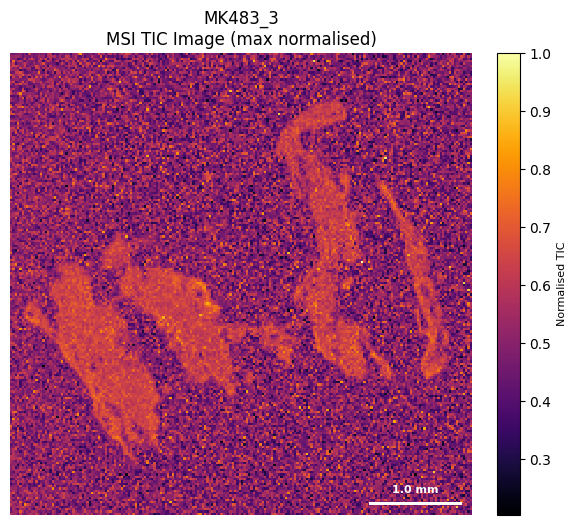

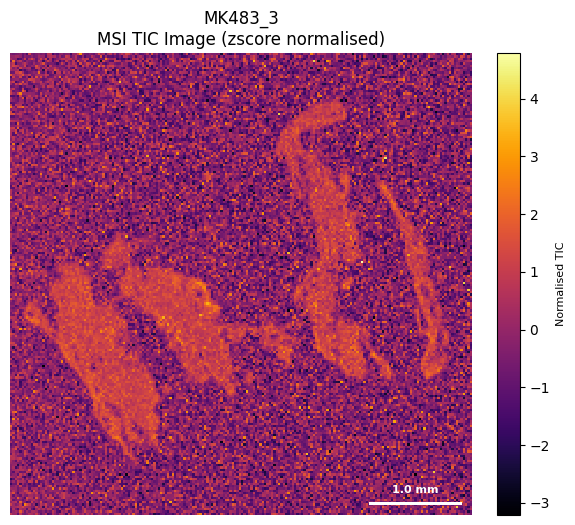

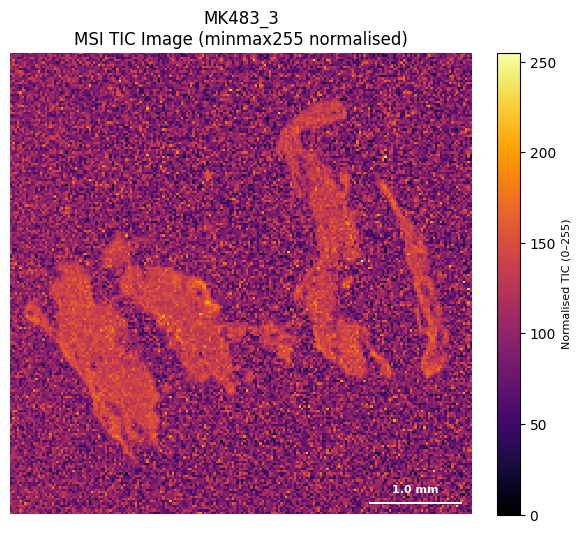

In [113]:
### Declare sample here ###
sample = 0
path = file_paths_aligned[sample]

for method in ['max', 'zscore', 'minmax255']:
    plot_tic(datacube_path=path, method=method, show_plot=True, show_bar = True)

We find that the normalisation method used simply sets the scale over which the normalised TIC intensities exist. For the rest of our analysis, we choose the `max` normalisation method, since it scales all intensities to the range [0,1], facilitating direct downstream machine learning implementation with minimal rescaling requirements.

## Plot & save all MSI TIC images

Let us now visualise all the samples in turn, and save them to a folder: `MSITIC_viz`

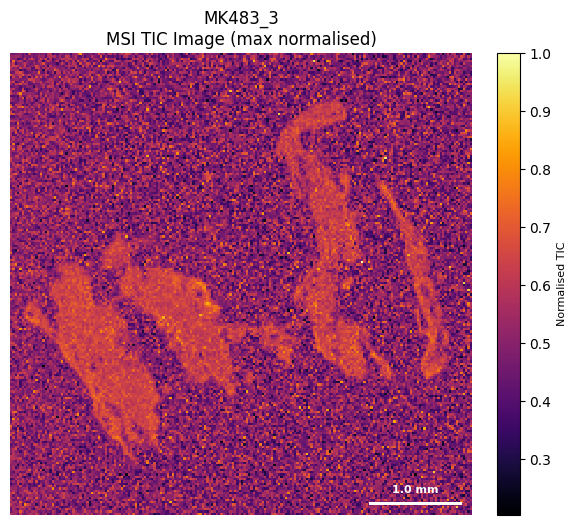

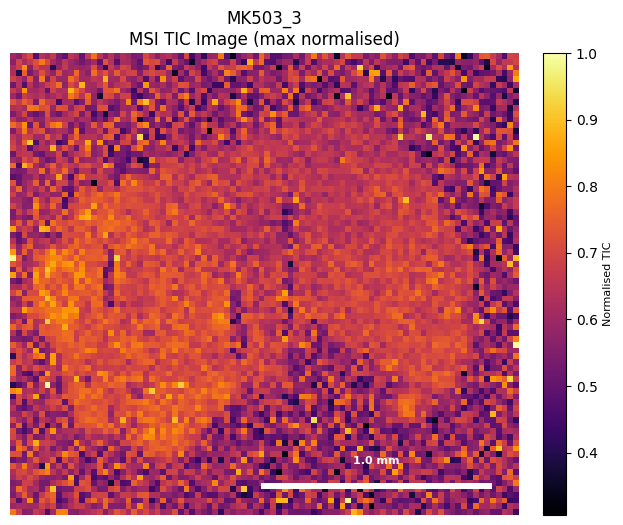

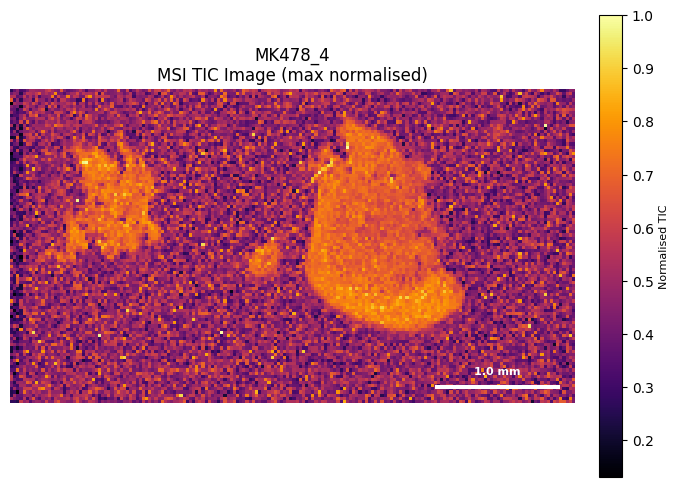

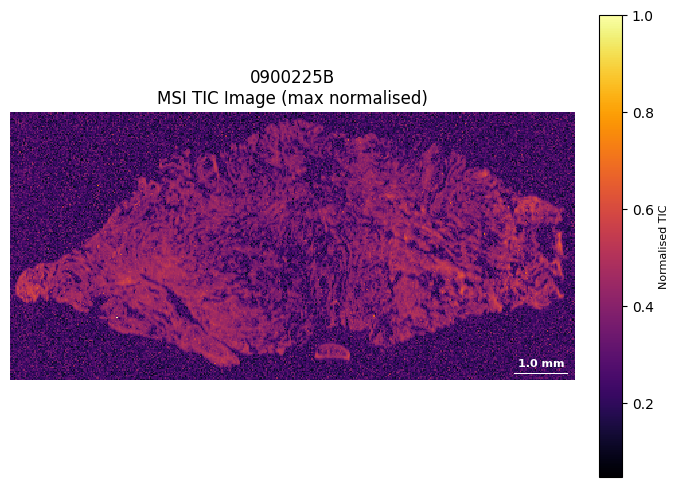

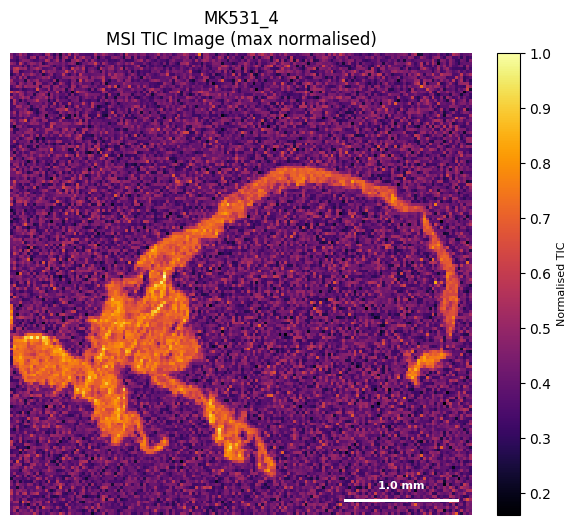

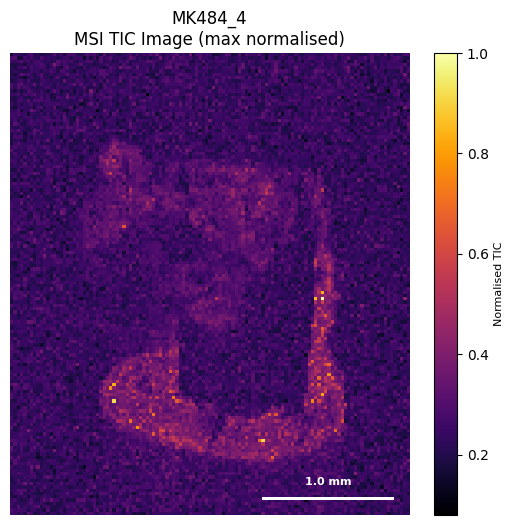

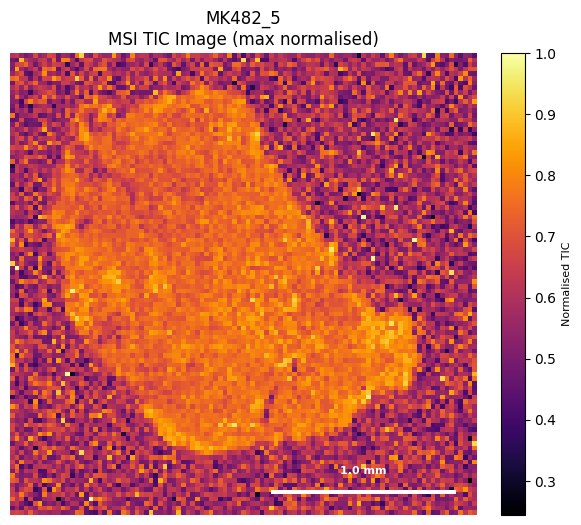

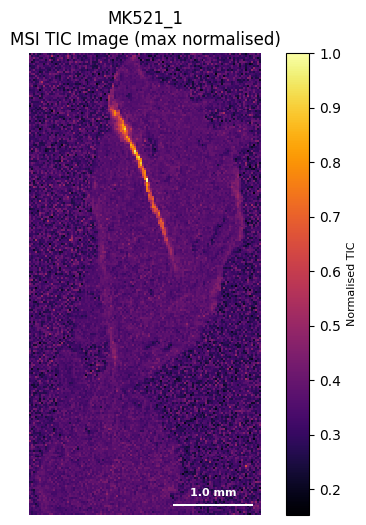

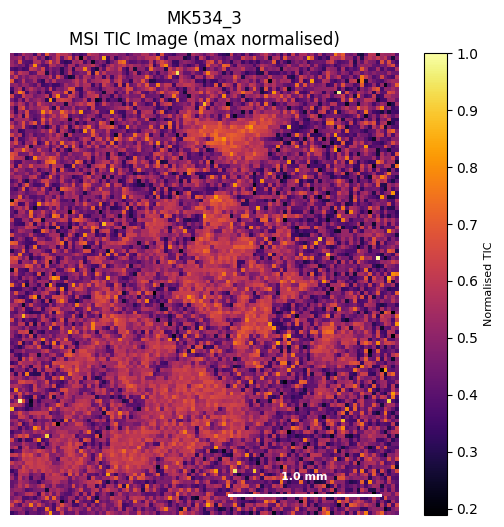

In [114]:
### Set output folder here ###
output_dir = 'MSITIC_viz'

for index, path in enumerate(file_paths_aligned):
    plot_tic(path, method='max', show_plot=True, save_plot = True, show_bar= True, output_dir = output_dir)

From the visualisations above, we notice a few things.

- The physical scales of the samples vary, but are all of the order of a few millimeters in both height and width. This size if typical for tissue samples used in MSI imaging procedures.
- The use of TIC to visualise the samples means that there is still significant contribution from the background (i.e. the non-sample regions) of the images.
- The intensities from the sample regions relative to their respective backgrounds vary considerably across samples.

We will need to bear these points in mind while designing the framework for our subsequent analysis.

## Visualising optical images of samples

For completeness and comparison, let us also visualise the optical images of samples after they have been H&E-stained (a special type of dye that highlights structures within tissue samples, enabling visual analysis to be performed by trained pathologists).

In [115]:
from PIL import Image

def plot_optical(
    img_path=None,
    show_plot=False,
    save_plot=False,
    output_dir=None,
    verbose=False
):
    """
    Displays and optionally saves an optical image (.png).

    Parameters
    ----------
    img_path : str or Path
        Path to the .png image to plot. Must be a valid file path.
    show_plot : bool, optional
        If True, displays the image after plotting. Fefault is False.
    save_plot : bool, optional
        If True, saves the plotted image to the specified output directory.
        Default is False.
    output_dir : str or Path, optional
        Directory to save the plotted image. Defaults to the parent of `img_path`.
    verbose : bool, optional
        If True, prints progress and save path. Default is False.

    Returns
    -------
    None
    """
    if not img_path:
        raise ValueError("You must provide a valid path to an image file (.png).")

    img_path = Path(img_path) if type(img_path) != pathlib.PosixPath else img_path
    
    if not img_path.exists():
        raise FileNotFoundError(f"Image file not found: {img_path}")

    # Load image
    img = Image.open(img_path)
    width, height = img.size

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_path.stem)
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)

    # Save
    if save_plot:
        output_dir = Path(output_dir) if output_dir else img_path.parent
        save_path = output_dir / f"{img_path.stem}_optical.png"
        fig.savefig(save_path, dpi=300, bbox_inches="tight", pad_inches=0)
        if verbose:
            print(f"Saved image to: {save_path}")

    if show_plot:
        plt.show()

    plt.clf()
    plt.close("all")

Let us first collect the paths to the `.png` files for each sample from our working directory.

In [116]:
png_file_paths = []

for f in folders:
    folder_path = Path(f)
    png_file_paths.extend(folder_path.rglob("*.png"))

print(f"Total number of images: {len(png_file_paths)}.\n")
for file_path in png_file_paths:
    print(file_path)

Total number of images: 9.

2024_07_22_MK483_3_25um_10Hz.raw/MK483-CIN1.png
2024_07_25_MK503_3_25um_10Hz.raw/MK503-CIN2.png
2024_07_23_MK478_4_25um_10Hz.raw/MK478_CIN1.png
2024_08_01_0900225B_25um_10Hz.raw/0900225B-NORMAL.png
2024_07_22_MK531_4_25um_10Hz.raw/MK531-CIN2.png
2024_07_29_MK484_4_25um_10Hz.raw/MK484-CIN2.png
2024_07_25_MK482_5_25um_10Hz.raw/MK482-INFLAMMATION.png
2024_07_18_MK521_1_25um_10Hz.raw/MK521_CIN1.png
2024_07_24_MK534_3_25um_10Hz.raw/MK534-CGIN.png


And then we plot each of the images, and save them to an ouput folder named `Optical_viz`.

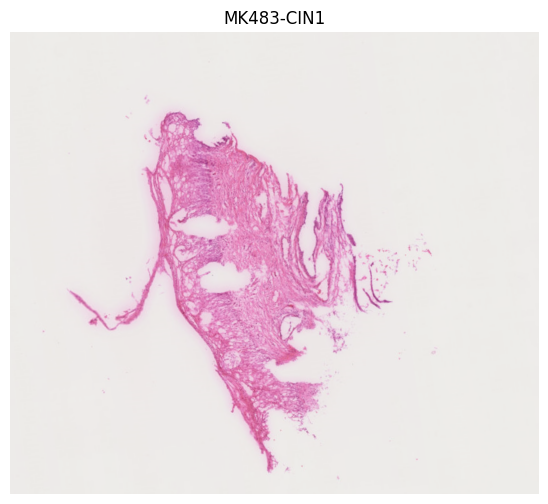

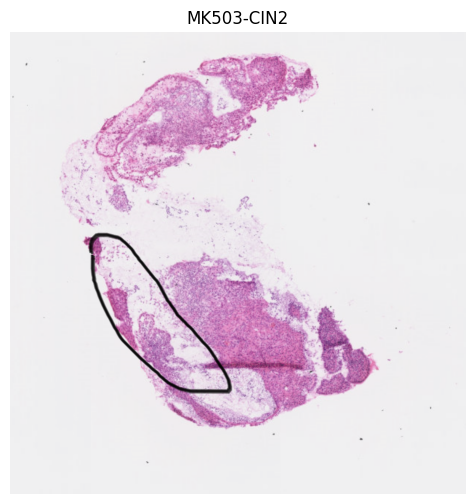

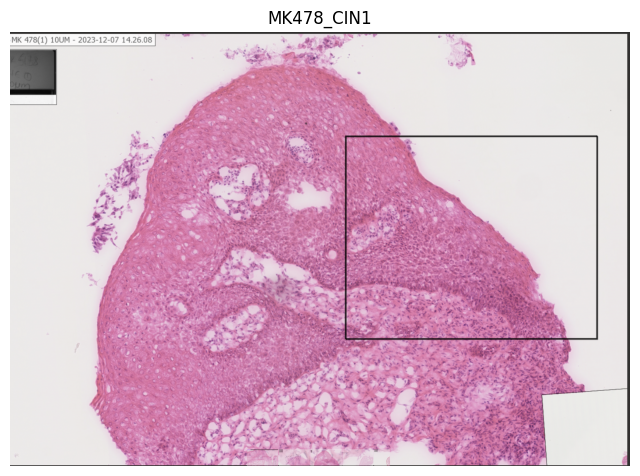

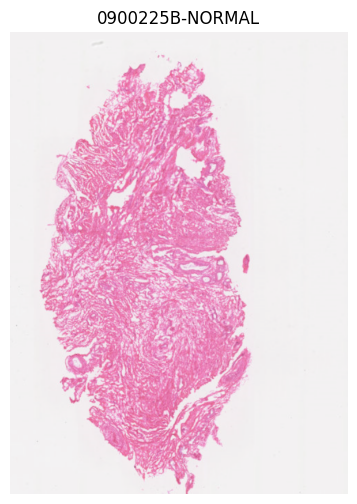

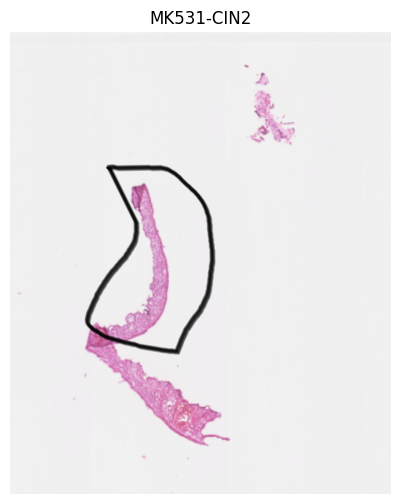

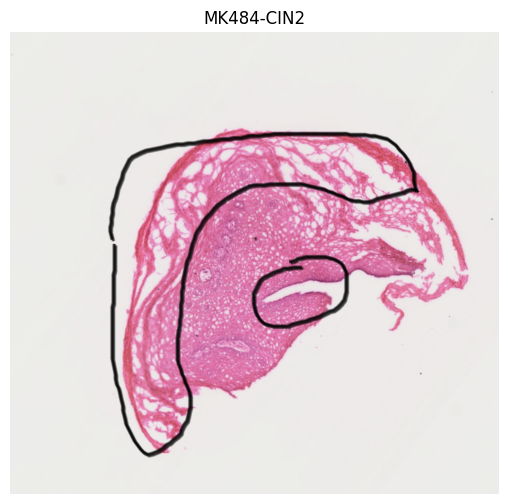

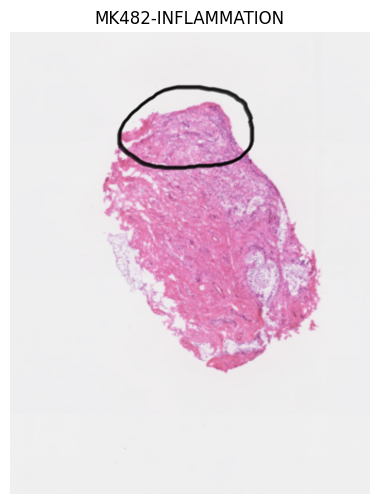

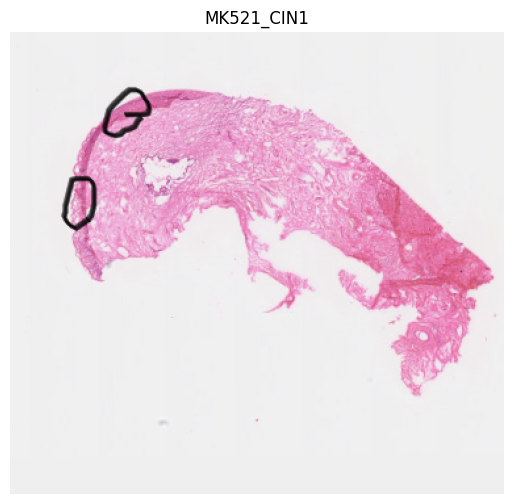

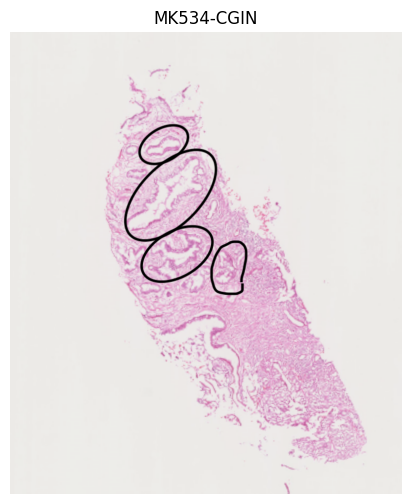

In [117]:
output_dir = "Optical_viz"

for index, path in enumerate(png_file_paths):
    plot_optical(img_path = path, show_plot = True, save_plot = True, output_dir  = output_dir)

We note that the optical images for each sample differ noticeably from the corresponding MSI TIC image. This is a consequence of the data collection procedure. Tissue samples are usually collected from a patient via a punch biopsy, which removes a small chunk of tissue from the patient. In this case, the chunk is removed from the cervix of the patient. Then fine slices are taken from the tissue section and used for diagnostics. Since the usage of H&E staining prevents imaging via MSI, adjacent sections of the tissue chunk are used for two different types of analysis, one for visual optical analysis, and the other for MSI-based analysis.

## Loading in pathology labellings

Now that we understand the data in the datacubes, we turn our attention to the `.csv` files and explore the data contained in them.

As before, we first collect the file paths:

In [118]:
csv_file_paths = []

for f in folders:
    folder_path = Path(f)
    csv_file_paths.extend([
        file_path for file_path in folder_path.rglob("*.csv")
        if not file_path.name.endswith("_imputed.csv") # if any files have missing data, these are imputed and saved 
    ])

print(f"Total number of CSV files: {len(csv_file_paths)}\n")
for file_path in csv_file_paths:
    print(file_path)

Total number of CSV files: 9

2024_07_22_MK483_3_25um_10Hz.raw/MK483_CSV.csv
2024_07_25_MK503_3_25um_10Hz.raw/MK503_CSV.csv
2024_07_23_MK478_4_25um_10Hz.raw/MK478_CSV.csv
2024_08_01_0900225B_25um_10Hz.raw/0900225B_normal.csv
2024_07_22_MK531_4_25um_10Hz.raw/MK531_CSV.csv
2024_07_29_MK484_4_25um_10Hz.raw/MK484_CSV.csv
2024_07_25_MK482_5_25um_10Hz.raw/MK482_CVS.csv
2024_07_18_MK521_1_25um_10Hz.raw/MK521_CIN1.csv
2024_07_24_MK534_3_25um_10Hz.raw/MK534_CSV.csv


Next, we construct a function to handle the loading, processing, and plotting necessary for the `.csv` files.

In [119]:
import pandas as pd

def inspect_csv(
    csv_path,
    show_summary=True,
    display_csv=False,
    show_plot=False,
    metadata_cols=('ID', 'Label'),
    save_plot=False,
    output_dir=None,
    return_df=False
):
    """
    Inspect an MSI ROI .csv file by summarising its contents, displaying basic
    statistics, and optionally plotting grouped mean spectra.

    Parameters
    ----------
    csv_path : str or Path
        Path to the .csv file containing the MSI ROI data.
    show_summary : bool, default=True
        If True, prints basic file statistics (row/column count, label counts).
    display_csv : bool, default=False
        If True, displays the first few rows of the dataframe.
    show_plot : bool, default=False
        If True, plots the mean spectra grouped by label.
    metadata_cols : tuple of str, default=('ID', 'Label')
        Names of non-spectral columns to exclude when identifying m/z features.
    save_plot : bool, default=False
        If True, saves the grouped mean spectra plot to disk.
    output_dir : str or Path, optional
        Directory to save the plot. Defaults to the parent of `csv_path`.
    return_df : bool, default=False
        If True, returns the loaded DataFrame.

    Returns
    -------
    pandas.DataFrame or None
        The loaded DataFrame, if `return_df=True`; otherwise None.
    """
    # === Validate and load file ===
    if not csv_path:
        raise ValueError("You must provide a valid path to a .csv file.")

    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"CSV file not found at: {csv_path}")

    df = pd.read_csv(csv_path)

    # === Summary info ===
    if show_summary:
        print(f"\nFile: {csv_path.name}")
        print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]:,}")
        if "Label" in df.columns:
            print("\nLabel distribution:")
            print(df["Label"].value_counts())
        else:
            print("\nNo 'Label' column found in this file.")

    if display_csv:
        display(df.head())

    # === Optional: Plot grouped mean spectra ===
    if show_plot or save_plot:
        if "Label" not in df.columns:
            raise ValueError("No 'Label' column found for grouping spectra.")

        # Identify m/z columns
        mz_columns = df.columns.difference(metadata_cols, sort=False)
        mz_values = np.array([float(mz) for mz in mz_columns])

        # Sort by m/z for plotting
        sorted_indices = np.argsort(mz_values)
        mz_values = mz_values[sorted_indices]

        labels = df["Label"].unique()
        colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))

        plt.figure(figsize=(10, 8))
        for i, label in enumerate(labels):
            group = df[df["Label"] == label]
            spectra = group[mz_columns].values[:, sorted_indices]

            mean_spectrum = np.mean(spectra, axis=0)
            std_spectrum = np.std(spectra, axis=0)

            plt.plot(
                mz_values, mean_spectrum,
                label=f"{label} (n={len(group)})",
                color=colors[i]
            )
            plt.fill_between(
                mz_values,
                np.clip(mean_spectrum - std_spectrum, a_min=0, a_max=None),
                mean_spectrum + std_spectrum,
                color=colors[i],
                alpha=0.25
            )

        plt.xlabel("m/z")
        plt.ylabel("Intensity")
        plt.title(f"Grouped Mean Spectrum ± Std. Dev.\n{csv_path.stem}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        # === Save and/or show plot ===
        if save_plot:
            output_dir = Path(output_dir) if output_dir else csv_path.parent
            save_path = output_dir / f"{csv_path.stem}_grouped_mean_spectra.png"
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"Plot saved to: {save_path}")

        if show_plot:
            plt.show()

        plt.close()

    if return_df:
        return df
    else:
        del df  # Free up memory

Let us consider one of the `.csv`'s and visualise its contents:

In [120]:
### Declare Sample Here ###
sample = 0
csv_path = csv_file_paths[sample]

inspect_csv(csv_path, display_csv = True)


File: MK483_CSV.csv
Rows: 827 | Columns: 2,949

Label distribution:
Label
CIN1      460
Normal    196
normal    171
Name: count, dtype: int64


,ID,Label,50.0094401672363,50.0688464477539,50.2138850524902,50.2588908508301,50.2893893554688,50.3882090881348,50.447840435791,50.6050822570801,...,1196.19197724609,1196.94295380859,1197.12715791016,1197.53121064453,1198.50252412109,1198.84285615234,1199.32515595703,1199.60176728516,1199.99214814453,1200.48873017578
0,1,CIN1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.391615,3.582057,3.582057,2.204799,0.0,0.0,0.0,0.0,0.0,0.0
1,2,CIN1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,3,CIN1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,4,CIN1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,5,CIN1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


We find that the layout of the `.csv`'s is transposed relative to the `.h5` files investigated before: the rows contain pixel-wise mass-spectral data now, and the columns are the m/z values over which the spectral data was recorded. We also find that the number of columns containing mass-spectral data (excluding 'Label' and 'ID') is the same as the number of rows in the corresponding (aligned) datacube. 

However, we note a mismatch in the opposite case, i.e., between the number of rows of the `.csv` and the number of columns of the datacube. In fact, the number of rows in the `.csv`'s are always smaller than their corresponding datacubes. This suggests that the data in each `.csv` is some subset of the data contained in its respective datacubes. We will explore this point in more detail later.

Lastly, we note that a pixel ID has been provided, and a pathologist label has been applied to each pixel.

Now, we iterate over all `.csv` files and save the plotted grouped mean spectra for each file into a folder: `MeanSpectra_Grouped`


File: MK483_CSV.csv
Rows: 827 | Columns: 2,949

Label distribution:
Label
CIN1      460
Normal    196
normal    171
Name: count, dtype: int64
Plot saved to: MeanSpectra_Grouped/MK483_CSV_grouped_mean_spectra.png


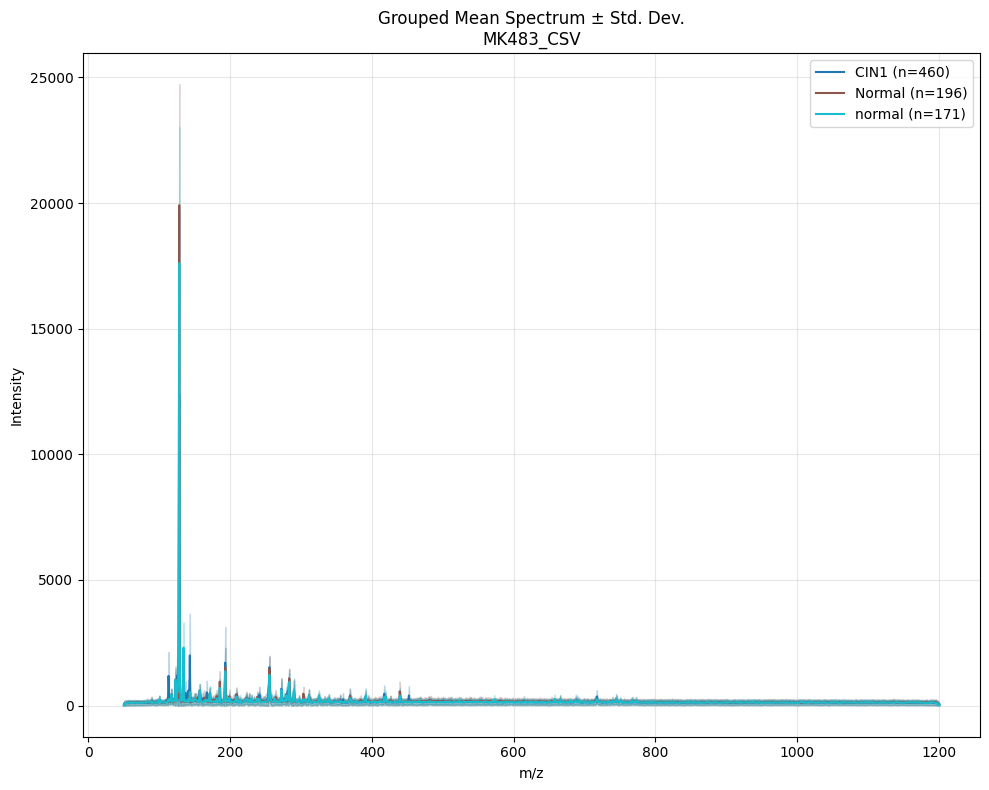


File: MK503_CSV.csv
Rows: 191 | Columns: 2,949

Label distribution:
Label
CIN2      164
NORMAL     27
Name: count, dtype: int64
Plot saved to: MeanSpectra_Grouped/MK503_CSV_grouped_mean_spectra.png


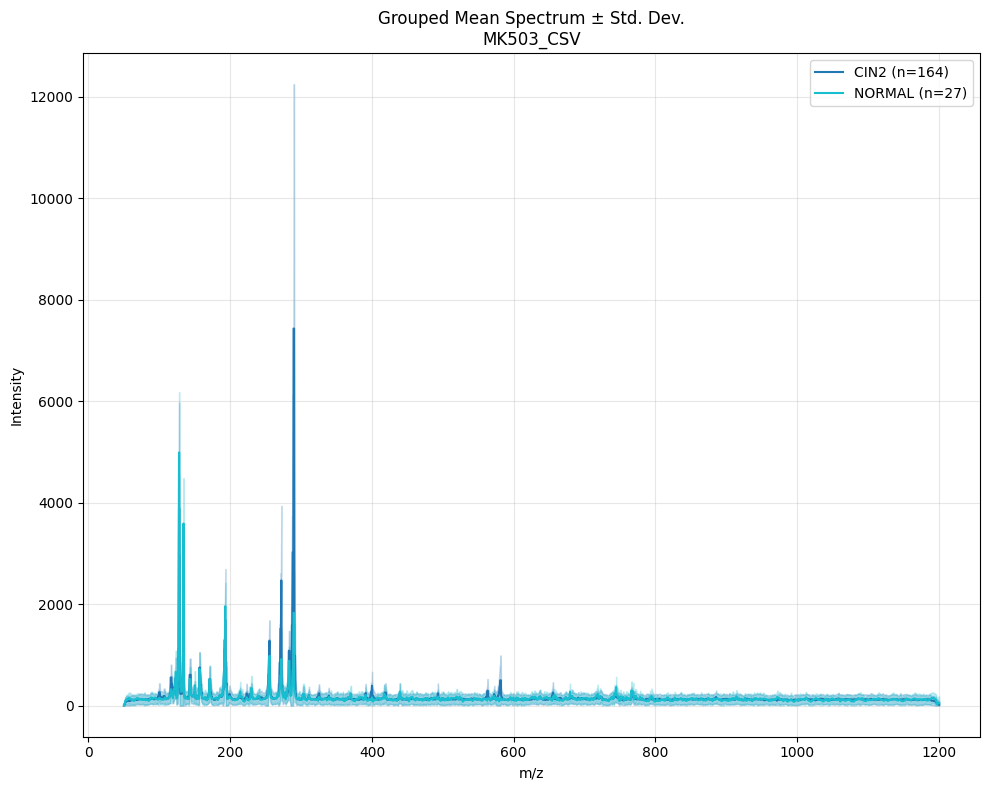


File: MK478_CSV.csv
Rows: 167 | Columns: 2,949

Label distribution:
Label
CIN2    167
Name: count, dtype: int64
Plot saved to: MeanSpectra_Grouped/MK478_CSV_grouped_mean_spectra.png


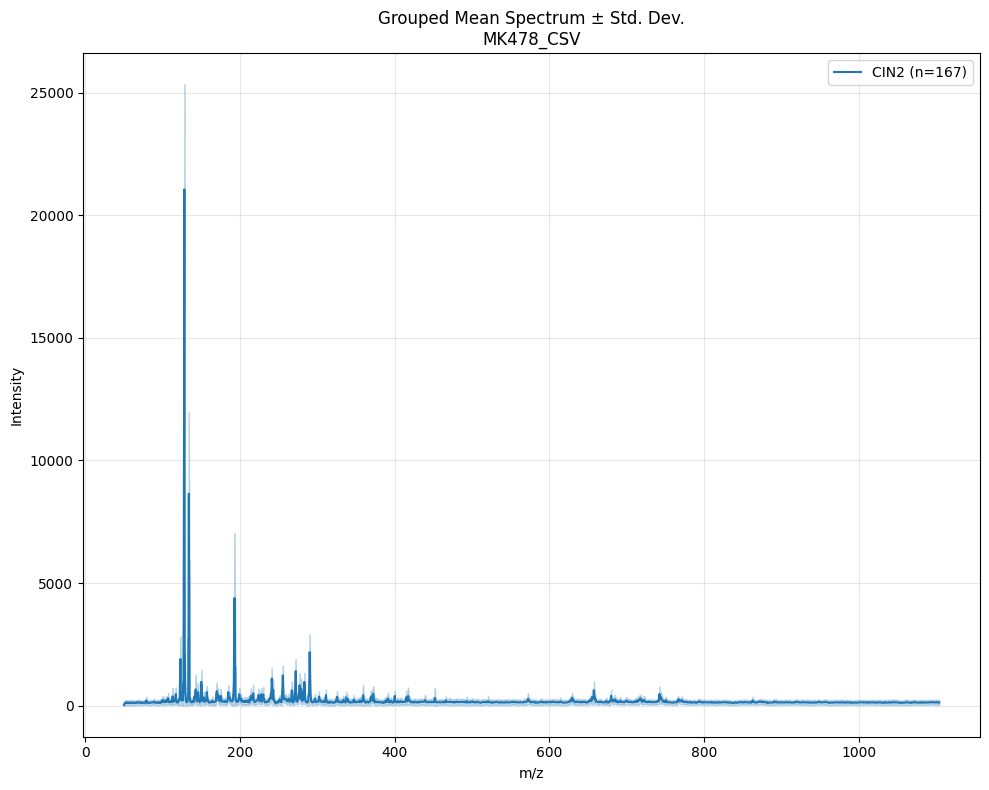


File: 0900225B_normal.csv
Rows: 755 | Columns: 2,949

Label distribution:
Label
normal 1    755
Name: count, dtype: int64
Plot saved to: MeanSpectra_Grouped/0900225B_normal_grouped_mean_spectra.png


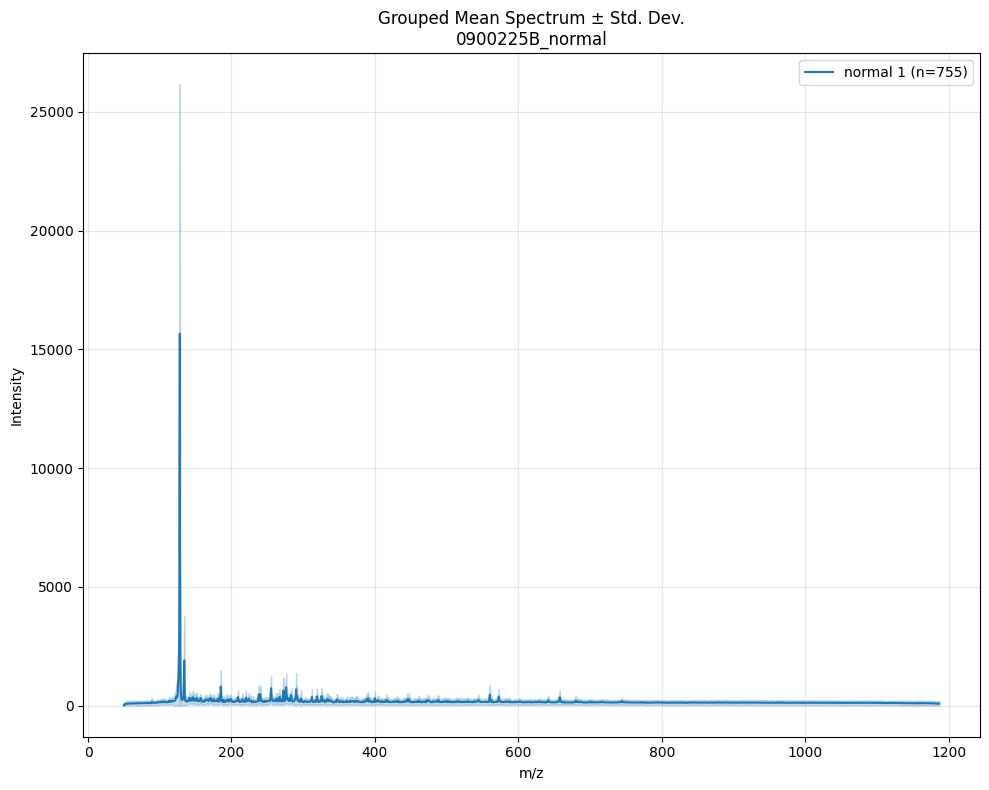


File: MK531_CSV.csv
Rows: 217 | Columns: 2,949

Label distribution:
Label
normal    74
Normal    60
CIN1      51
CIN2      32
Name: count, dtype: int64
Plot saved to: MeanSpectra_Grouped/MK531_CSV_grouped_mean_spectra.png


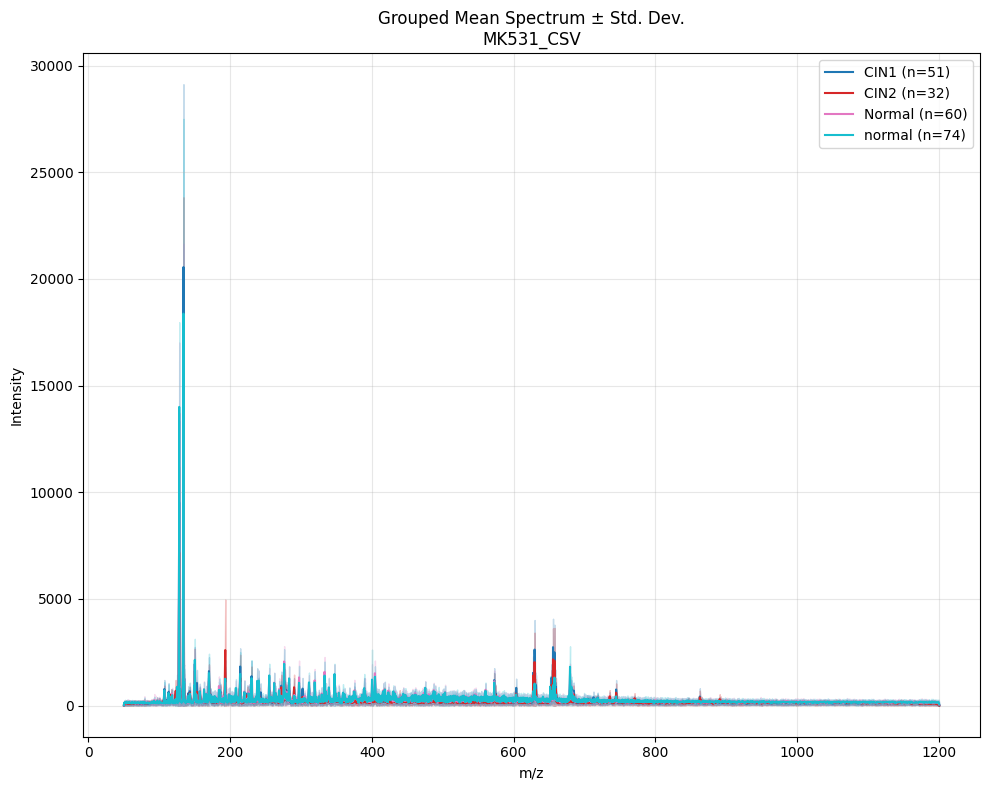


File: MK484_CSV.csv
Rows: 281 | Columns: 2,949

Label distribution:
Label
CIN1      196
NORMAL     85
Name: count, dtype: int64
Plot saved to: MeanSpectra_Grouped/MK484_CSV_grouped_mean_spectra.png


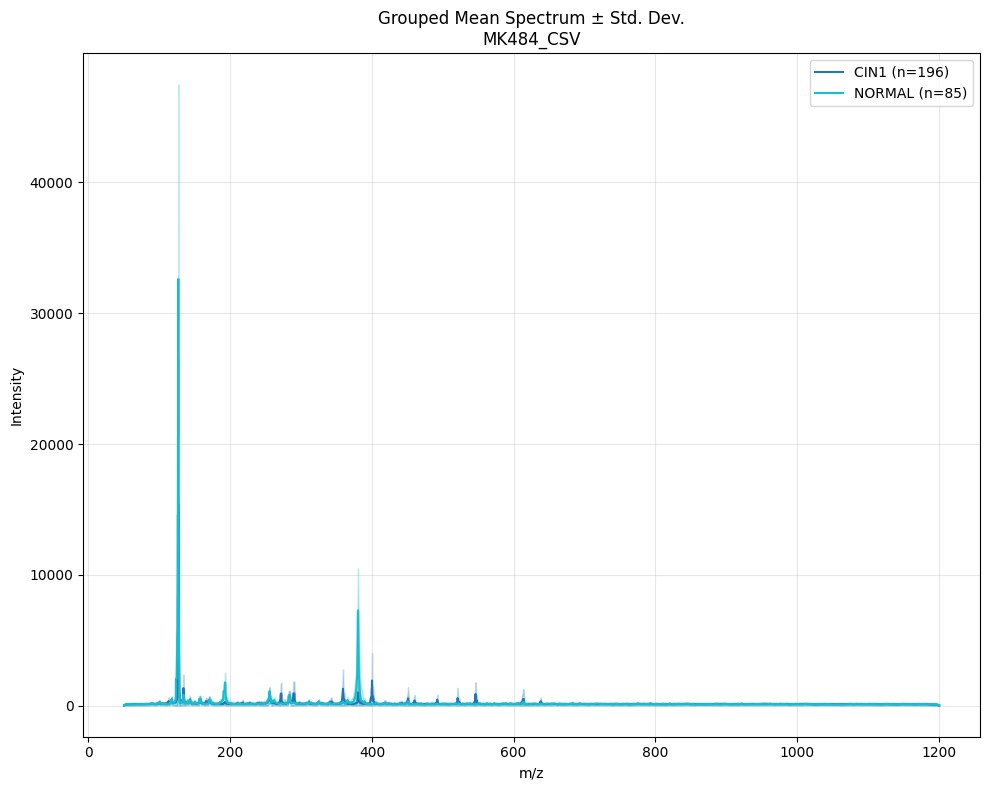


File: MK482_CVS.csv
Rows: 152 | Columns: 2,949

Label distribution:
Label
HPV INFECTION    97
NORMAL           55
Name: count, dtype: int64
Plot saved to: MeanSpectra_Grouped/MK482_CVS_grouped_mean_spectra.png


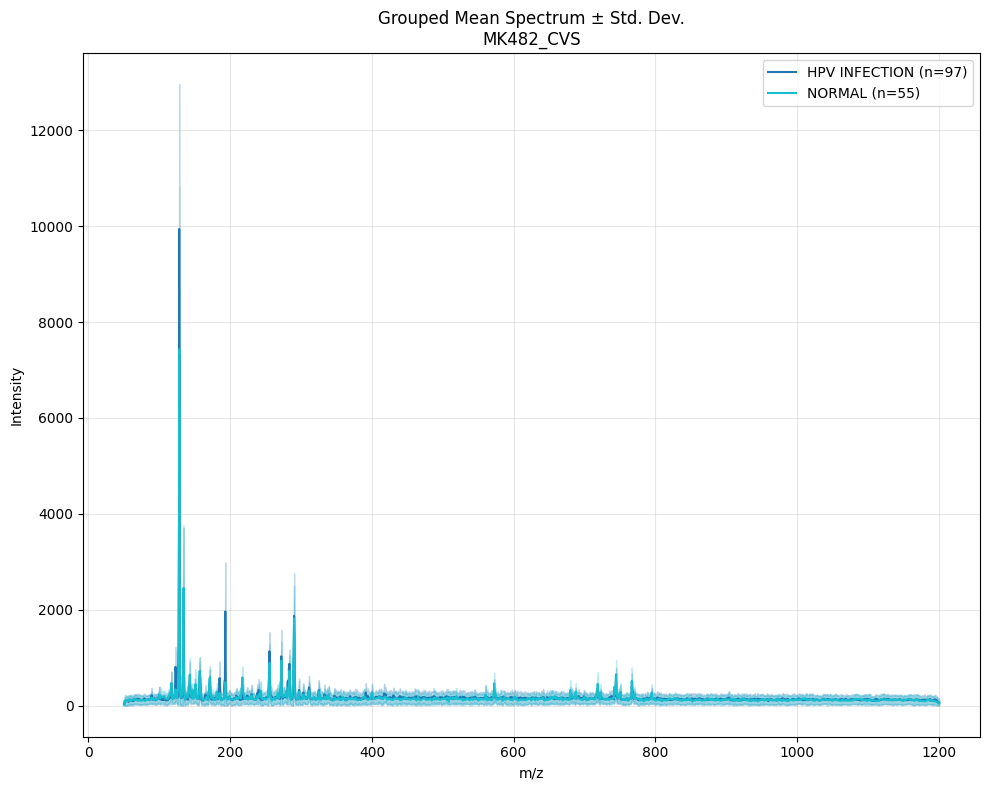


File: MK521_CIN1.csv
Rows: 369 | Columns: 2,949

Label distribution:
Label
CIN1      188
NORMAL    181
Name: count, dtype: int64
Plot saved to: MeanSpectra_Grouped/MK521_CIN1_grouped_mean_spectra.png


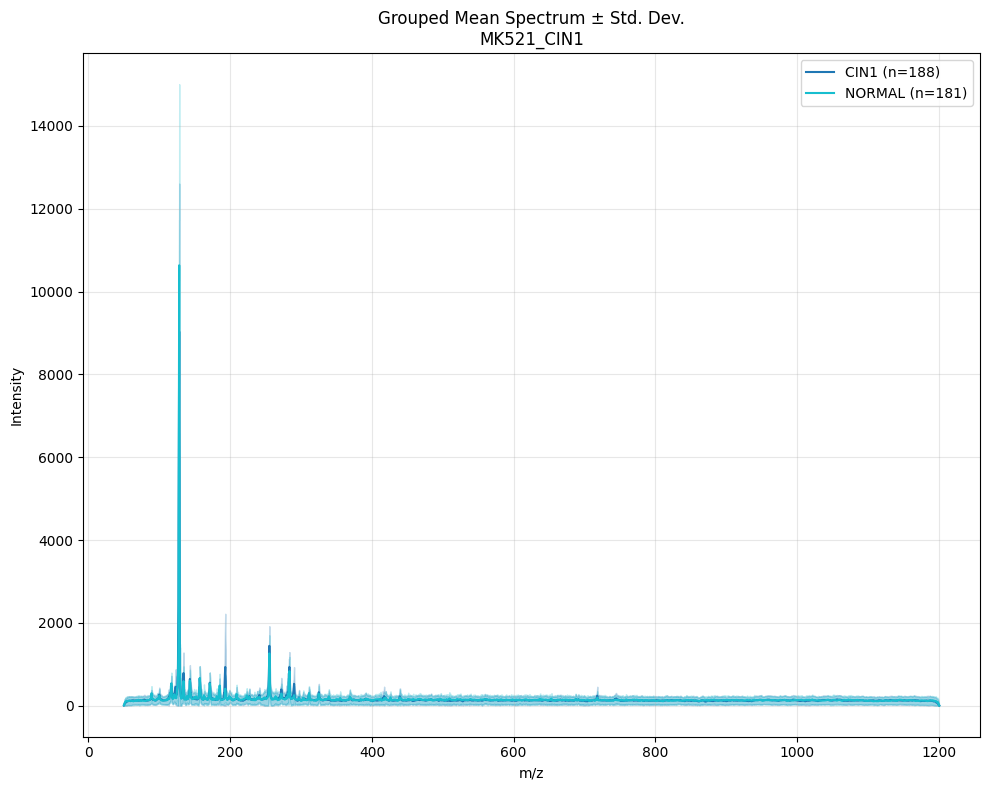


File: MK534_CSV.csv
Rows: 106 | Columns: 2,949

Label distribution:
Label
CGIN      73
NORMAL    33
Name: count, dtype: int64
Plot saved to: MeanSpectra_Grouped/MK534_CSV_grouped_mean_spectra.png


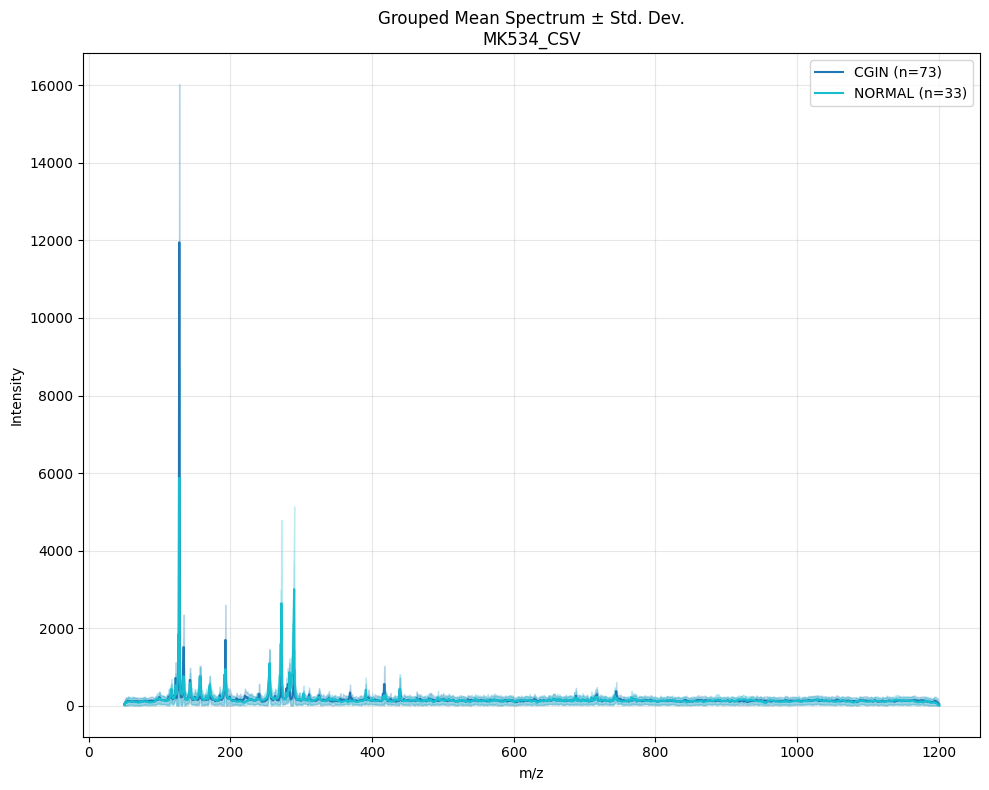

In [121]:
output_dir = "MeanSpectra_Grouped"

for index, csv_path in enumerate(csv_file_paths):
    inspect_csv(csv_path = csv_path, show_plot = True, save_plot = True, output_dir=output_dir)

We also perform a quick count of the number of rows across all `.csv`'s combined. This is important, since each row in the `.csv` files corresponds to the spectral data for a single pixel, and we will be using this data as our training, validation, and testing data for our ML implementation later on, using the pathologist labelling as the ground truth.

In [122]:
# Quick count of number of labelled pixels across all samples
row_counts = []
for index, csv_path in enumerate(csv_file_paths):
    loaded = csv_file_paths[index]
    df_ = pd.read_csv(loaded)
    print(f"File: {csv_path}\n Shape: {df_.shape}\n")
    row_counts.append(df_.shape[0])
print(f"Total number of labelled pixels: {np.sum(np.array(row_counts))}.")

File: 2024_07_22_MK483_3_25um_10Hz.raw/MK483_CSV.csv
 Shape: (827, 2949)

File: 2024_07_25_MK503_3_25um_10Hz.raw/MK503_CSV.csv
 Shape: (191, 2949)

File: 2024_07_23_MK478_4_25um_10Hz.raw/MK478_CSV.csv
 Shape: (167, 2949)

File: 2024_08_01_0900225B_25um_10Hz.raw/0900225B_normal.csv
 Shape: (755, 2949)

File: 2024_07_22_MK531_4_25um_10Hz.raw/MK531_CSV.csv
 Shape: (217, 2949)

File: 2024_07_29_MK484_4_25um_10Hz.raw/MK484_CSV.csv
 Shape: (281, 2949)

File: 2024_07_25_MK482_5_25um_10Hz.raw/MK482_CVS.csv
 Shape: (152, 2949)

File: 2024_07_18_MK521_1_25um_10Hz.raw/MK521_CIN1.csv
 Shape: (369, 2949)

File: 2024_07_24_MK534_3_25um_10Hz.raw/MK534_CSV.csv
 Shape: (106, 2949)

Total number of labelled pixels: 3065.


## Data imputation

Before proceeding any further, let us ensure that there are no missing values in our `.csv`'s since this will make our downstream analysis more inconvenient. We will also check if the `NaN`'s occur in continuous blocks, or in individual pixels. If they occur in blocks, then the imputation can be simplified further.

In [123]:
def check_nans(df, check_consecutive=True):
    """
    Check for NaN values in the rows of a DataFrame, 
    stores and returns the column indices where NaNs occur. 
    Optionally verifies if they appear consecutively.

    Parameters
    ----------
    df : pandas.DataFrame
        The DataFrame whose rows are checked for NaN values.
    check_consecutive : bool, optional
        If True, determines whether the NaNs in each row occur in consecutive
        columns. Default is True.

    Returns
    -------
    dict
        A dictionary keyed by row index. Each value contains:
          - 'nan_columns' : list of integer indices of columns containing NaNs.
          - 'consecutive' : bool (only present if `check_consecutive=True`),
            indicating whether the NaNs are consecutive.
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError("Input must be a pandas DataFrame.")
    if df.empty:
        raise ValueError("The provided DataFrame is empty.")

    results = {}
    for idx, row in df.iterrows():
        nan_mask = row.isna().values
        nan_indices = np.where(nan_mask)[0]

        if nan_indices.size == 0:
            continue  # skip rows with no NaNs

        if check_consecutive:
            is_consecutive = (
                len(nan_indices) == 1 or np.all(np.diff(nan_indices) == 1)
            )
            results[idx] = {
                "nan_columns": nan_indices.tolist(),
                "consecutive": is_consecutive
            }
        else:
            results[idx] = {"nan_columns": nan_indices.tolist()}

    return results

In [124]:
for i, csv_path in enumerate(csv_file_paths):
    print(f'Sample: {csv_file_paths[i].stem}')
    df = pd.read_csv(csv_path)
    print(f"Shape: {df.shape}")
    try:
        results_i = check_nans(df)
        print(results_i)
        total_nans = df.isna().sum().sum()
        print(f'Number of missing values in .csv file: {total_nans} \n')
    except Exception as e:
        print("Error loading CSV file:")
        print(e)

Sample: MK483_CSV
Shape: (827, 2949)
{}
Number of missing values in .csv file: 0 

Sample: MK503_CSV
Shape: (191, 2949)
{}
Number of missing values in .csv file: 0 

Sample: MK478_CSV
Shape: (167, 2949)
{166: {'nan_columns': [2730, 2731, 2732, 2733, 2734, 2735, 2736, 2737, 2738, 2739, 2740, 2741, 2742, 2743, 2744, 2745, 2746, 2747, 2748, 2749, 2750, 2751, 2752, 2753, 2754, 2755, 2756, 2757, 2758, 2759, 2760, 2761, 2762, 2763, 2764, 2765, 2766, 2767, 2768, 2769, 2770, 2771, 2772, 2773, 2774, 2775, 2776, 2777, 2778, 2779, 2780, 2781, 2782, 2783, 2784, 2785, 2786, 2787, 2788, 2789, 2790, 2791, 2792, 2793, 2794, 2795, 2796, 2797, 2798, 2799, 2800, 2801, 2802, 2803, 2804, 2805, 2806, 2807, 2808, 2809, 2810, 2811, 2812, 2813, 2814, 2815, 2816, 2817, 2818, 2819, 2820, 2821, 2822, 2823, 2824, 2825, 2826, 2827, 2828, 2829, 2830, 2831, 2832, 2833, 2834, 2835, 2836, 2837, 2838, 2839, 2840, 2841, 2842, 2843, 2844, 2845, 2846, 2847, 2848, 2849, 2850, 2851, 2852, 2853, 2854, 2855, 2856, 2857, 2858, 

We now know that there are `NaN`'s in the last rows of both samples 2 and 3, and we also know the starting positions of the `NaN`'s in these rows, and that they run uninterrupted until the ends of the rows.

This allows us to perform imputation in a straight forward manner, making the DataFrames usable for downstream analysis. We can simply fill these in using 0's, since they only occur in single rows in the DataFrames they are present.

To allow a more general approach to imputation, let us construct a function to perform simple imputation of a DataFrame based on a number of user-specified imputation methods.

In [125]:
def impute_df(df, method='constant', fill_val=0, group_col=None,
             verbose=False):
    """
    Imputes missing values in numerical columns of a DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame
        The DataFrame to impute.
    method : {'constant', 'mean', 'median', 'mode'}, optional
        Imputation method:
        - 'constant' : fills NaNs with `fill_val`.
        - 'mean' : fills NaNs with the column mean.
        - 'median' : fills NaNs with the column median.
        - 'mode' : fills NaNs with the most frequent value (mode) of the column.
        Default is 'constant'.
    fill_val : int or float, optional
        Constant value used when `method='constant'`. Default is 0.
    group_col : str, optional
        Column used to group rows for group-wise imputation. Defaults to None.
    verbose : bool, optional
        If True, prints the imputation method used, and which column has been
        used to group the entries of the DataFrame. Default is False.

    Returns
    -------
    pandas.DataFrame
        DataFrame with missing numerical values imputed.
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError("Input must be a pandas DataFrame.")
    if df.empty:
        raise ValueError("The provided DataFrame is empty.")

    valid_methods = ('constant', 'mean', 'median', 'mode')
    if method not in valid_methods:
        raise ValueError(f"Parameter 'method' must be one of {valid_methods}.")

    if method != 'constant':
        fill_val = "per-column "+method

    df_impute = df.copy()
    numeric_cols = df_impute.select_dtypes(include='number').columns

    if verbose:
            print(f"Imputing using method: {method}, with value: {fill_val}. Grouping using column: {group_col}.")
        
    numeric_cols = df_impute.select_dtypes(include=np.number).columns

    if group_col and group_col in df_impute.columns:
        # Grouped imputation
        for col in numeric_cols:
            if method == 'constant':
                df_impute[col] = df_impute[col].fillna(fill_val)
            elif method == 'mean':
                df_impute[col] = df_impute.groupby(group_col)[col].transform(lambda x: x.fillna(x.mean()))
            elif method == 'median':
                df_impute[col] = df_impute.groupby(group_col)[col].transform(lambda x: x.fillna(x.median()))
            elif method == 'mode':
                df_impute[col] = df_impute.groupby(group_col)[col].transform(lambda x: x.fillna(x.mode()[0]))
    else:
        # Non-grouped imputation
        if method == 'constant':
            df_impute[numeric_cols] = df_impute[numeric_cols].fillna(fill_val)
        elif method == 'mean':
            df_impute[numeric_cols] = df_impute[numeric_cols].fillna(df_impute[numeric_cols].mean())
        elif method == 'median':
            df_impute[numeric_cols] = df_impute[numeric_cols].fillna(df_impute[numeric_cols].median())
        elif method == 'mode':
            df_impute[numeric_cols] = df_impute[numeric_cols].fillna(df_impute[numeric_cols].mode().iloc[0])

    return df_impute

And also a function that uses `impute_df()` to run the imputation and optionally save the imputed file (to a specified location):

In [126]:
def run_imputation(csv_path, 
                   return_imputed=False,
                   save_imputed=False,
                   save_folder=None,
                   verbose=False):
    """
    Runs imputation on a retrieved .csv file using the `impute_df()` function.

    Parameters
    ----------
    csv_path : str or Path
        Path to the .csv file containing the MSI ROI data.
    return_imputed : bool, optional
        If True, returns the imputed DataFrame.
        Default is False.
    save_imputed : bool, optional
        If True, saves the imputed DataFrame as a .csv file.
        Default is False.
    save_folder : str or Path, optional
        Custom save directory for the imputed .csv file.
        If None, saves to the same folder as the original with '_imputed' suffix.
    verbose : bool, optional
        If True, prints progress messages. Default is False.

    Returns
    -------
    pandas.DataFrame or None
        The imputed DataFrame if `return_imputed=True`.
    """
    csv_path = Path(csv_path)

    if verbose:
        print(f"Imputing file: {csv_path.name} ...")

    # Load and impute
    df = pd.read_csv(csv_path)
    df_impute = impute_df(df)

    if verbose:
        print("Imputation complete.")

    # Save if requested
    if save_imputed:
        updated_name = csv_path.stem + "_imputed" + csv_path.suffix
        save_dir = Path(save_folder) if save_folder else csv_path.parent
        save_path = save_dir / updated_name

        df_impute.to_csv(save_path, index=False)

        if verbose:
            print(f"Imputed .csv file successfully saved to: {save_path}.")
    print("\n")
    
    if return_imputed:
        return df_impute

In [127]:
# --- Setup ---
impute_samples = (2,3)

for sample in impute_samples:
    full_path = csv_file_paths[sample]
    run_imputation(full_path, verbose = True, save_imputed = True)

Imputing file: MK478_CSV.csv ...
Imputation complete.
Imputed .csv file successfully saved to: 2024_07_23_MK478_4_25um_10Hz.raw/MK478_CSV_imputed.csv.


Imputing file: 0900225B_normal.csv ...
Imputation complete.
Imputed .csv file successfully saved to: 2024_08_01_0900225B_25um_10Hz.raw/0900225B_normal_imputed.csv.




## ROI overlays on MSI images

Now that we have visualised and cleaned the `.csv` files, we need to consider the distribution of annotated pixels on the MSI samples themselves. This will add context to the results of our ML-based analysis later on.

Let us first construct a function that takes the contents of the .csv file (as `pandas.DataFrame`) and the finds the matching regions in the .h5 file (as a `numpy.ndarray`). To expedite the matching process and to maintain reasonable memory usage, we will need to implement additonal steps.

Using `cosine_similarity` from `sklearn.metrics.pairwise` allows for fast and direct comparison of the mass spectra in the two data sources. Further, we incorporate a chunked processing approach that reduces memory overheads while the pixel-matching algorithm is running.

In [128]:
from sklearn.metrics.pairwise import cosine_similarity
import math

def match_pixels(df, datacube,
                metadata_cols=['ID', 'Label'], label_col='Label',
                chunk_size=50, return_matching=False,
                verbose=False):
    """
    Matches rows in .csv's to the closest .h5 datacube column using
    chunked cosine similarity. Handles NaNs in both .csv's and datacubes
    internally. 

    Parameters
    ----------
    df : pandas.DataFrame
        Contains the annotated ROIs in the MSI data.

    datacube : numpy.ndarray
        Contains the overall MSI data (n_mz x n_pixels).

    metadata_cols : list, optional
        The columns of the DataFrame containing non-mass spectral data.
        Default is ['ID', 'Label'].
        
    label_col : str, optional
        The column of the DataFrame containing the pathologist-assigned
        annotation. Default is 'Label'.

    chunk_size : int, optional
        Number of CSV pixels processed per chunk in the similarity
        calculation. Default is 50.

    return_matching : bool, optional
        If True, return the array of matched pixels from the datacube.

    verbose : bool, optional
        If True, prints additional information regarding the pixel matching
        procedure. Default is False.
    
    Returns
    -------
    label_mask : np.ndarray
        Full label mask for the datacube (aligned to n_pixels in datacube).
        
    spectra_array : np.ndarray or None
        Matched spectra from the datacube (n_mz x n_valid_csv_pixels), 
        only if `return_matching=True`; otherwise None.
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError("The input parameter `df` must be a pandas.DataFrame")
    if not isinstance(datacube, np.ndarray):
        raise TypeError("The input parameter `datacube` must be a numpy.ndarray")
    if datacube.ndim != 2:
        raise ValueError("The datacube must be a 2D numpy array.")
    
    # Transpose datacube: m/z x pixels -> pixels x m/z
    _datacube = datacube.T  

    # Remove datacube rows (pixels) with NaNs
    valid_cube_rows = ~np.isnan(_datacube).any(axis=1)
    cube_clean = _datacube[valid_cube_rows, :].astype(np.float32)

    # Extract CSV spectra (pixels x m/z) and labels
    csv_spectra = df.drop(columns=metadata_cols).to_numpy().astype(np.float32)
    labels = df[label_col].to_numpy()

    # Remove .csv rows (pixels) with NaNs
    valid_csv_rows = ~np.isnan(csv_spectra).any(axis=1)
    csv_clean = csv_spectra[valid_csv_rows, :]
    labels_clean = labels[valid_csv_rows]
    print(labels_clean.shape)

    if csv_clean.shape[0] == 0:
        raise ValueError("All CSV spectra contain NaNs: nothing to match.")

    if cube_clean.shape[1] != csv_clean.shape[1]:
        raise ValueError(f"Mismatch in m/z dimensions: .h5 -> {cube_clean.shape[1]}, .csv -> {csv_clean.shape[1]}")

    # Match indices
    match_row_indices = np.zeros(csv_clean.shape[0], dtype=int)
    if len(match_row_indices) == 0:
        raise ValueError("No valid matches found between CSV and datacube.")

    if verbose:
        print(f"Matching {csv_clean.shape} .csv to {cube_clean.shape} .h5...")
    
    # Chunked pixel matching
    for start in range(0, csv_clean.shape[0], chunk_size):
        if verbose:
            print(f"Processing chunk {start // chunk_size + 1}/{math.ceil(csv_clean.shape[0] / chunk_size)}.")
        end = min(start + chunk_size, csv_clean.shape[0])
        chunk = csv_clean[start:end, :]
        sim = cosine_similarity(cube_clean, chunk)
        # pick pixel that most closely matches between df and datacube
        match_row_indices[start:end] = sim.argmax(axis=0)

    if verbose:
        print("Pixel matching complete.\n")

    # Extract matched spectra from the cleaned datacube
    spectra_array = cube_clean[match_row_indices, :].T if return_matching else None

    # Build full label mask for the original datacube
    label_mask = np.empty(_datacube.shape[0], dtype=object)
    label_mask[:] = ''
    
    mask_indices = np.where(valid_cube_rows)[0]  # positions in full datacube
    label_mask[mask_indices[match_row_indices]] = labels_clean

    return label_mask, spectra_array

This pixel matching process (a kind of inverse problem?...) is particularly prone to dying kernels, and we recommend using a chunk size of about 50 pixels for all samples analysed.

Now, we make a function that we can call repeatedly to carry out the pixel matching procedure for each sample, and also save the label masks produced (at a specified location, as before).

In [129]:
def run_match_pixels(csv_path, datacube_path,
                     return_label_mask=False,
                     save_label_mask=False, save_folder=None,
                     save_name = None,
                     verbose=False):
    """
    Performs one complete run of the pixel matching algorithm
    given the locations of .csv and .h5 files in the current
    working directory. Optionally saves the label mask generated
    to a specified location, and prints additional information
    on the status of the current run of the algorithm and file
    saving.

    Parameter
    ---------
    csv_path : str or Path
        Path to the .csv file containing the MSI ROI data.

    datacube_path : str or Path
        Path to the .h5 datacube file.

    return_label_mask : bool, optional
        If True, returns the label mask produced.

    save_label_mask : bool, optional
        If True, enables saving of the label mask produced
        from the pixel matching algorithm.
        
    save_folder : None, optional
        Specifies the location to which the label mask is saved.
        Defaults to None, and saves to the same location as the
        datacube (also happens to be the .csv location here).
        
    verbose : bool, optional
        If True, prints additional information with the status
        of the pixel matching run and saving, if enabled.

    Returns
    -------
    numpy.ndarray or None
        The label mask produced if `return_label_mask=True`.
    """
    csv_path = Path(csv_path)
    datacube_path = Path(datacube_path)

    # default to the folder from which the .h5 and .csv are loaded
    save_folder = csv_path.parent if not save_folder else save_folder

    # and also define the name under which mask is saved if not specified
    save_name = 'labelled_mask' if not save_name else save_name # used this default for consistency in naming

    if not csv_path.exists():
        raise FileNotFoundError(f"Specified file does not exist: {csv_path}")

    if not datacube_path.exists():
        raise FileNotFoundError(f"Specified file does not exist: {datacube_path}")

    df = pd.read_csv(csv_path)
    datacube = keyload_h5(datacube_path, dataset_key='datacube', return_dataset=True)
    print(datacube_path)

    label_mask, spectra_array = match_pixels(df=df, datacube=datacube, verbose=verbose)
    print(np.unique(label_mask))

    if save_label_mask:
        np.save(save_folder/f'{save_name}.npy', label_mask)
        if verbose:
            print(f"Saved label mask to: {save_folder / f'{save_name}.npy'}\n")

    if return_label_mask:
        return label_mask 

In [130]:
for i, path in enumerate(csv_file_paths):
    save_folder = path.parent
    sample_name = save_folder.stem
    print(f"Sample: {sample_name}")
    label_mask = run_match_pixels(csv_path = path,
                                  datacube_path = file_paths_aligned[i],
                                  verbose=True, save_label_mask = True, 
                                  save_folder = save_folder) # used default naming for masks

Sample: 2024_07_22_MK483_3_25um_10Hz
2024_07_22_MK483_3_25um_10Hz.raw/datacube_aligned.h5
(827,)
Matching (827, 2947) .csv to (40000, 2947) .h5...
Processing chunk 1/17.
Processing chunk 2/17.
Processing chunk 3/17.
Processing chunk 4/17.
Processing chunk 5/17.
Processing chunk 6/17.
Processing chunk 7/17.
Processing chunk 8/17.
Processing chunk 9/17.
Processing chunk 10/17.
Processing chunk 11/17.
Processing chunk 12/17.
Processing chunk 13/17.
Processing chunk 14/17.
Processing chunk 15/17.
Processing chunk 16/17.
Processing chunk 17/17.
Pixel matching complete.

['' 'CIN1' 'Normal' 'normal']
Saved label mask to: 2024_07_22_MK483_3_25um_10Hz.raw/labelled_mask.npy

Sample: 2024_07_25_MK503_3_25um_10Hz
2024_07_25_MK503_3_25um_10Hz.raw/datacube_aligned.h5
(191,)
Matching (191, 2947) .csv to (7040, 2947) .h5...
Processing chunk 1/4.
Processing chunk 2/4.
Processing chunk 3/4.
Processing chunk 4/4.
Pixel matching complete.

['' 'CIN2' 'NORMAL']
Saved label mask to: 2024_07_25_MK503_3_25um

In [131]:
# Store file paths for the label masks
mask_paths = [folder + '/labelled_mask.npy' for folder in folders]
print(f'Number of unaligned files: {len(mask_paths)}\n')
for mask_path in mask_paths:
    print(f'File path: {mask_path}')

Number of unaligned files: 9

File path: 2024_07_22_MK483_3_25um_10Hz.raw/labelled_mask.npy
File path: 2024_07_25_MK503_3_25um_10Hz.raw/labelled_mask.npy
File path: 2024_07_23_MK478_4_25um_10Hz.raw/labelled_mask.npy
File path: 2024_08_01_0900225B_25um_10Hz.raw/labelled_mask.npy
File path: 2024_07_22_MK531_4_25um_10Hz.raw/labelled_mask.npy
File path: 2024_07_29_MK484_4_25um_10Hz.raw/labelled_mask.npy
File path: 2024_07_25_MK482_5_25um_10Hz.raw/labelled_mask.npy
File path: 2024_07_18_MK521_1_25um_10Hz.raw/labelled_mask.npy
File path: 2024_07_24_MK534_3_25um_10Hz.raw/labelled_mask.npy


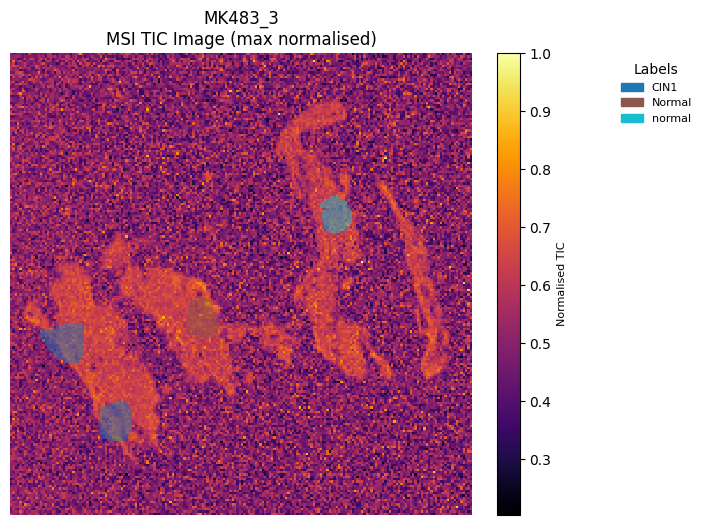

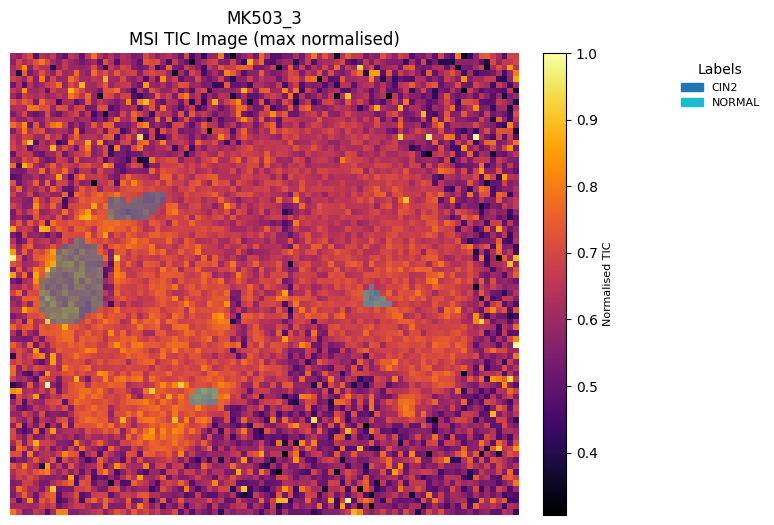

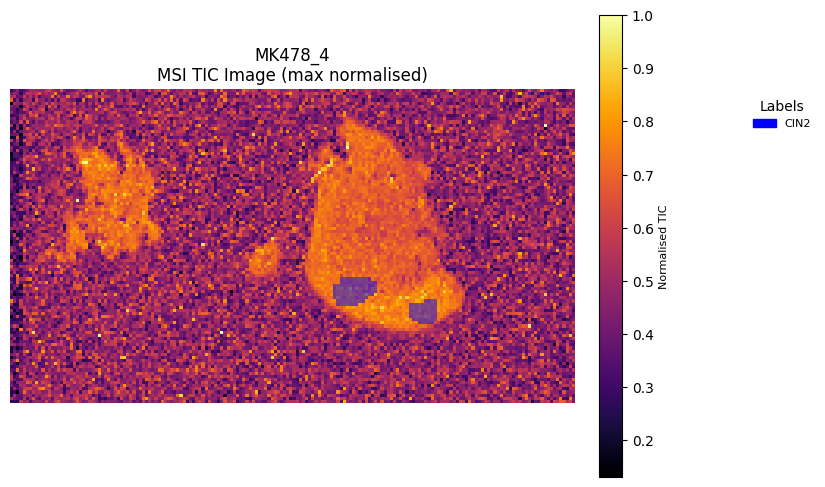

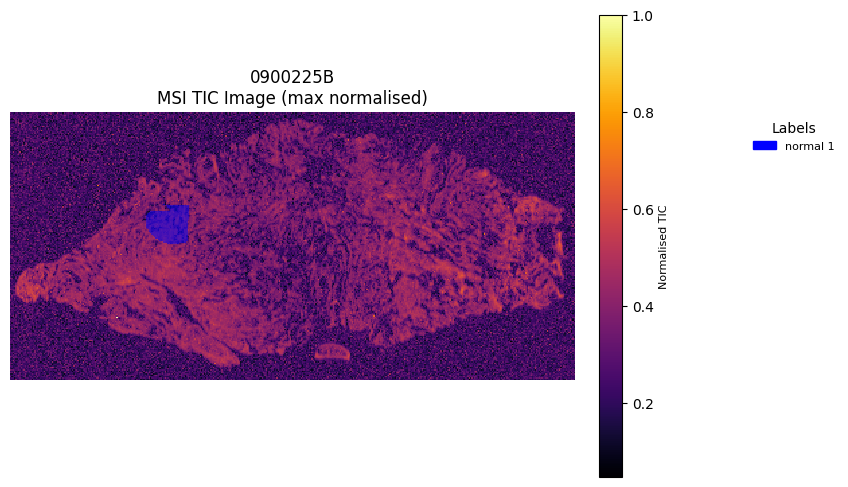

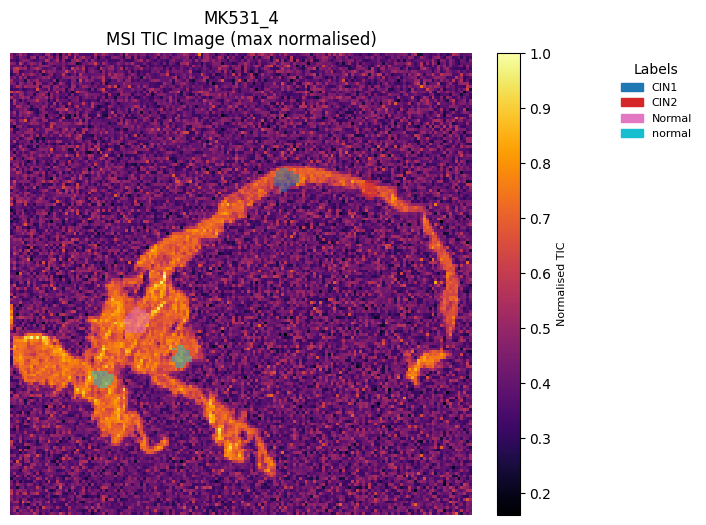

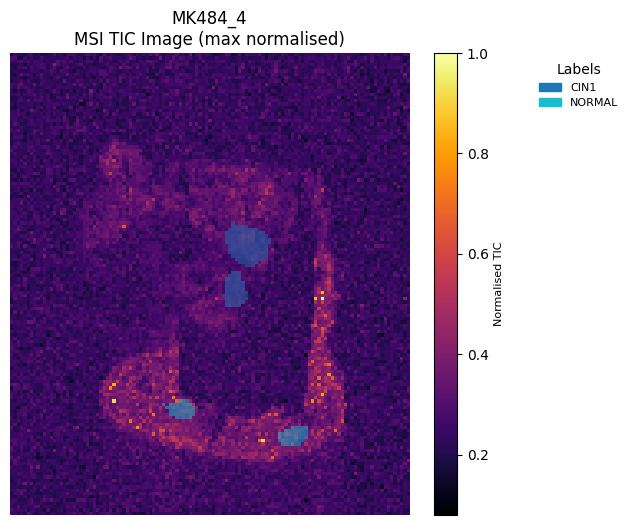

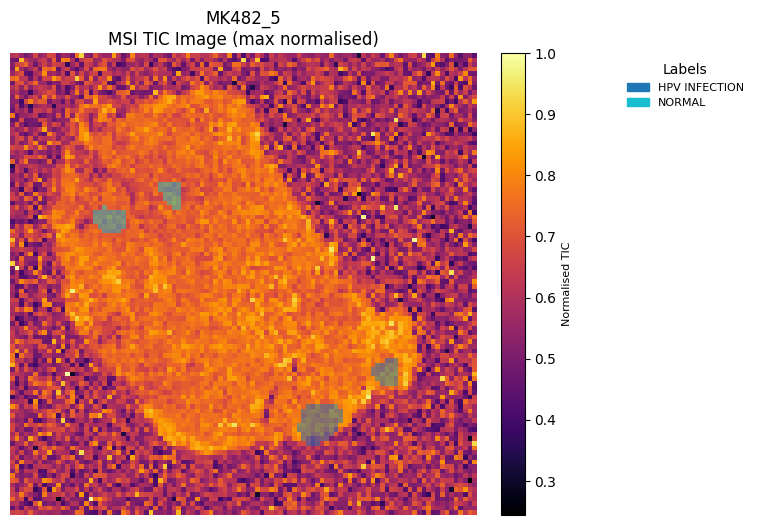

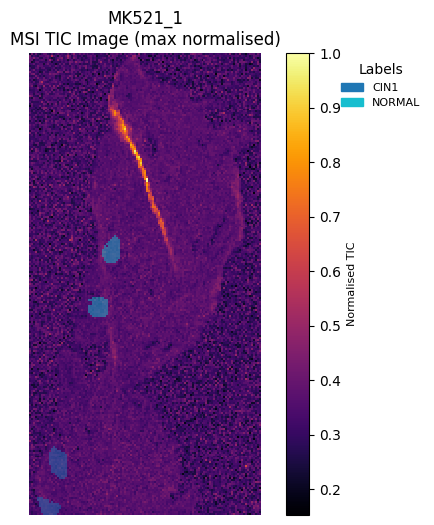

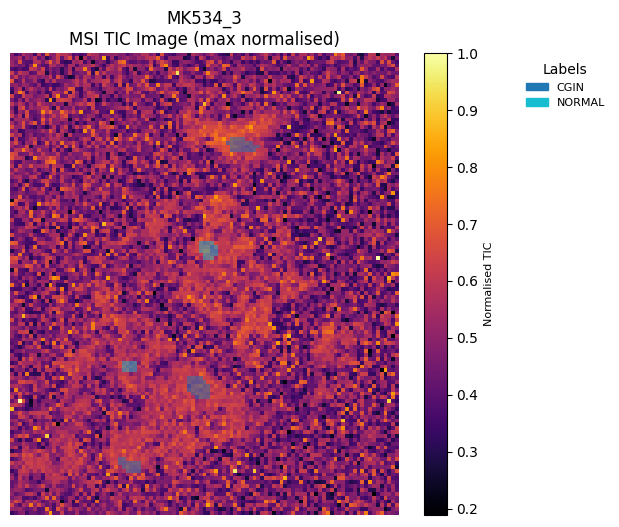

In [132]:
output_dir = 'ROIs_Overlaid'

for i, mask_path in enumerate(mask_paths):
    plot_tic(datacube_path = file_paths_aligned[i], show_plot = True, show_roi = True, roi_mask_path = mask_path,
            save_plot = True, output_dir = output_dir, roi_cmap = 'tab10', roi_alpha = 0.5)